# Random Forests for Regression tasks
A regression task attempts at predicting the value of a continuous target label, given an unseen set of feature data.

In this lecture we will be using Random Forest Regression, but first we'll be trying other models to make a comparision of performance on the task at hand:
* Linear Regression
* Polynomial Regression
* KNN Regression
* Decision tree Regression
* Support Vector Regression
* Boosted Trees Regression
* Random Forest Regression

We will see that some models will not be performing well with the kind of sigmoid input data we get for the feature data of the case.

## Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('../../jupyter_notebooks/DATA/rock_density_xray.csv')
df

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374
...,...,...
295,0.700227,2.112965
296,58.586585,2.000293
297,54.674548,1.879181
298,15.162434,2.644990


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rebound Signal Strength nHz  300 non-null    float64
 1   Rock Density kg/m3           300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Rebound Signal Strength nHz,300.0,49.725766,28.341792,0.700227,25.685798,50.602886,74.854294,98.831658
Rock Density kg/m3,300.0,2.225063,0.314512,1.500000,1.987830,2.268597,2.476944,2.750000


In [5]:
df.columns=['Signal','Density']

<Axes: xlabel='Signal', ylabel='Density'>

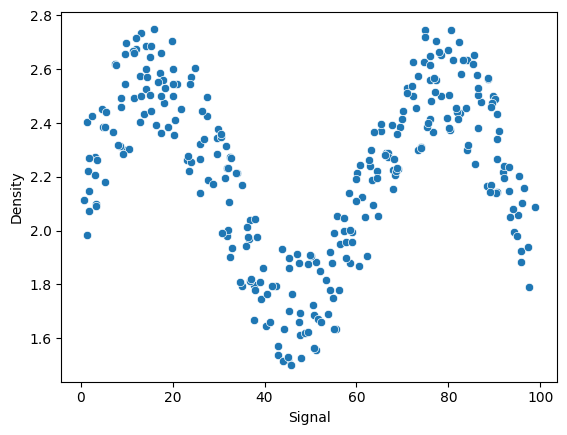

In [6]:
sns.scatterplot(x='Signal',y='Density',data=df)

In [7]:
X=df['Signal']
y=df['Density']

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=101)

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lr_model = LinearRegression()

In [12]:
lr_model.fit(X_train,y_train)

ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

# Common error: provide an array, while a DataFrame is expected.
What happened was that our data is just a single feature, so df['Signal'] is just an array of values, so the model gets confused as whether it is a single feature with several observatios or a single observation of several features. We have to reshape it to make it acceptable by the model

In [13]:
X=df['Signal'].values.reshape(-1,1)

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=101)

In [15]:
lr_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
lr_preds=lr_model.predict(X_test)
lr_preds

array([2.22029657, 2.22047771, 2.22035637, 2.22034337, 2.22039737,
       2.22050555, 2.22042659, 2.22028877, 2.22034673, 2.22029714,
       2.22041506, 2.22050153, 2.22043891, 2.22042003, 2.22047022,
       2.22032403, 2.22033377, 2.22030628, 2.22035154, 2.22035373,
       2.22029266, 2.22036798, 2.22033018, 2.22030611, 2.22042754,
       2.22044019, 2.2204142 , 2.22040303, 2.22048946, 2.22047495])

In [17]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [18]:
mean_absolute_error(y_test,lr_preds)

0.211198973318633

In [19]:
np.sqrt(mean_squared_error(y_test,lr_preds))

np.float64(0.2570051996584629)

All in all, error doesn't seem too far off: about 10% in average. "In average" is the problem: this linear regression cannot learn a sinusoid pattern, but the metrics doesn't show it too farr off.

Let's see the plot again.

<Axes: xlabel='Signal', ylabel='Density'>

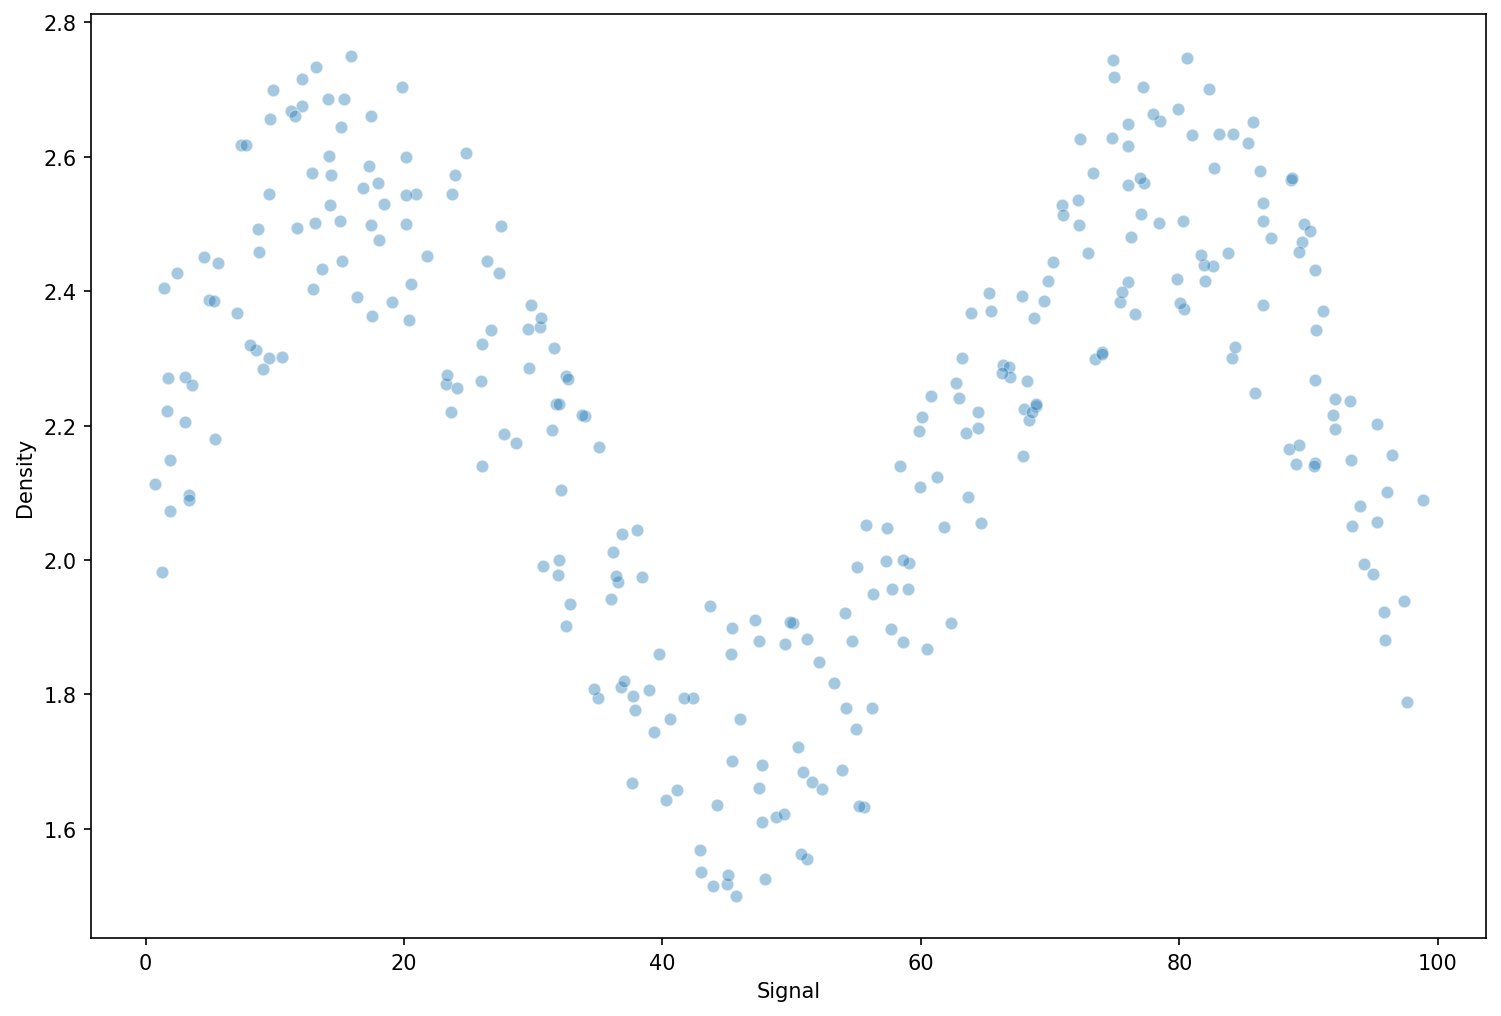

In [20]:
plt.figure(figsize=(12,8),dpi=150)
sns.scatterplot(x='Signal',y='Density',data=df,alpha=0.4)

Now, let's see the signal range

In [21]:
signal_range = np.arange(0,100)
signal_range

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

Let's predict for all the signal rage.

In [22]:
signal_preds = lr_model.predict(signal_range.reshape(-1,1))
signal_preds

array([2.22028446, 2.22028673, 2.22028899, 2.22029126, 2.22029353,
       2.22029579, 2.22029806, 2.22030032, 2.22030259, 2.22030485,
       2.22030712, 2.22030938, 2.22031165, 2.22031391, 2.22031618,
       2.22031844, 2.22032071, 2.22032297, 2.22032524, 2.2203275 ,
       2.22032977, 2.22033204, 2.2203343 , 2.22033657, 2.22033883,
       2.2203411 , 2.22034336, 2.22034563, 2.22034789, 2.22035016,
       2.22035242, 2.22035469, 2.22035695, 2.22035922, 2.22036148,
       2.22036375, 2.22036602, 2.22036828, 2.22037055, 2.22037281,
       2.22037508, 2.22037734, 2.22037961, 2.22038187, 2.22038414,
       2.2203864 , 2.22038867, 2.22039093, 2.2203932 , 2.22039546,
       2.22039773, 2.22039999, 2.22040226, 2.22040453, 2.22040679,
       2.22040906, 2.22041132, 2.22041359, 2.22041585, 2.22041812,
       2.22042038, 2.22042265, 2.22042491, 2.22042718, 2.22042944,
       2.22043171, 2.22043397, 2.22043624, 2.2204385 , 2.22044077,
       2.22044304, 2.2204453 , 2.22044757, 2.22044983, 2.22045

It is predicting about the same values for the whole signal range.

Let's plot it.

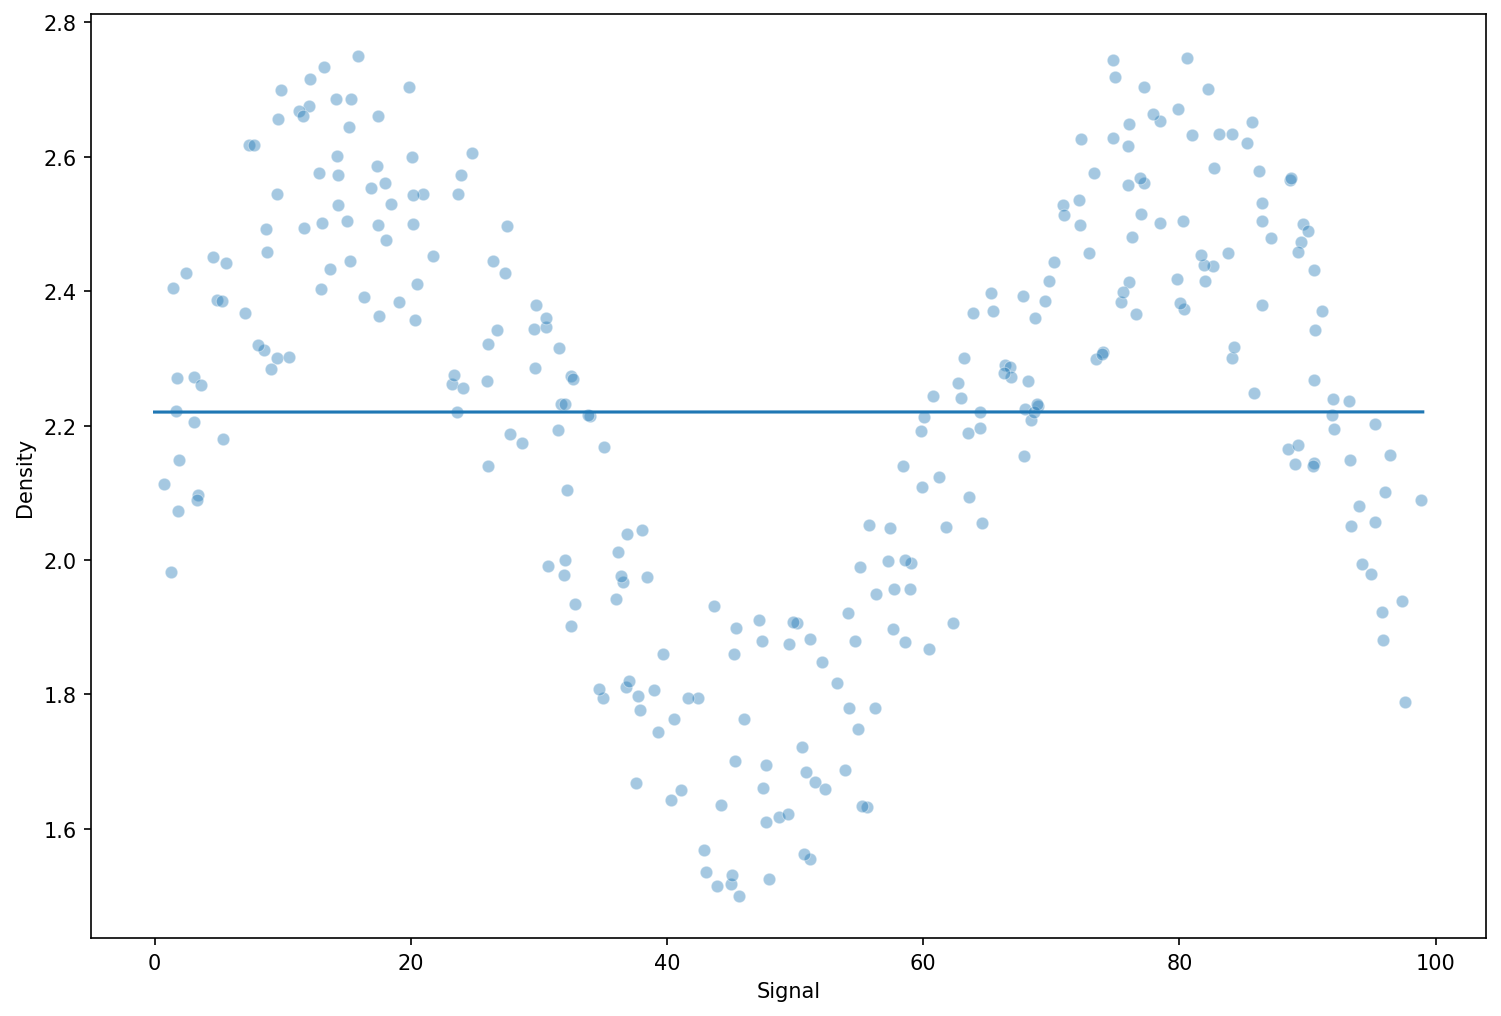

In [23]:
plt.figure(figsize=(12,8),dpi=150)
sns.scatterplot(x='Signal',y='Density',data=df,alpha=0.4)
plt.plot(signal_range,signal_preds)

It is trying to fit everything to the average line of 2.22.

# Polynomial regression
We will see that, although it fits the predictions to a curve, the real predictions --one by one, that is-- are way off and not acceptable at all.

Let's build a function that will allow us to easily build that plot for every regression method we try.

In [24]:
def run_model(model,X_train,y_train,X_test,y_test):
    model.fit(X_train,y_train)
    preds=model.predict(X_test)
    rmse=np.sqrt(mean_squared_error(y_test,preds))
    mae=mean_absolute_error(y_test,preds)
    print(f'MAE: {mae}')
    print(f'RMSE: {rmse}')
    signal_range=np.arange(0,100)
    output=model.predict(signal_range.reshape(-1,1))
    plt.figure(figsize=(12,6),dpi=150)
    sns.scatterplot(x='Signal',y='Density',data=df,alpha=0.4,color='black',s=5)
    plt.plot(signal_range,output)

MAE: 0.211198973318633
RMSE: 0.2570051996584629


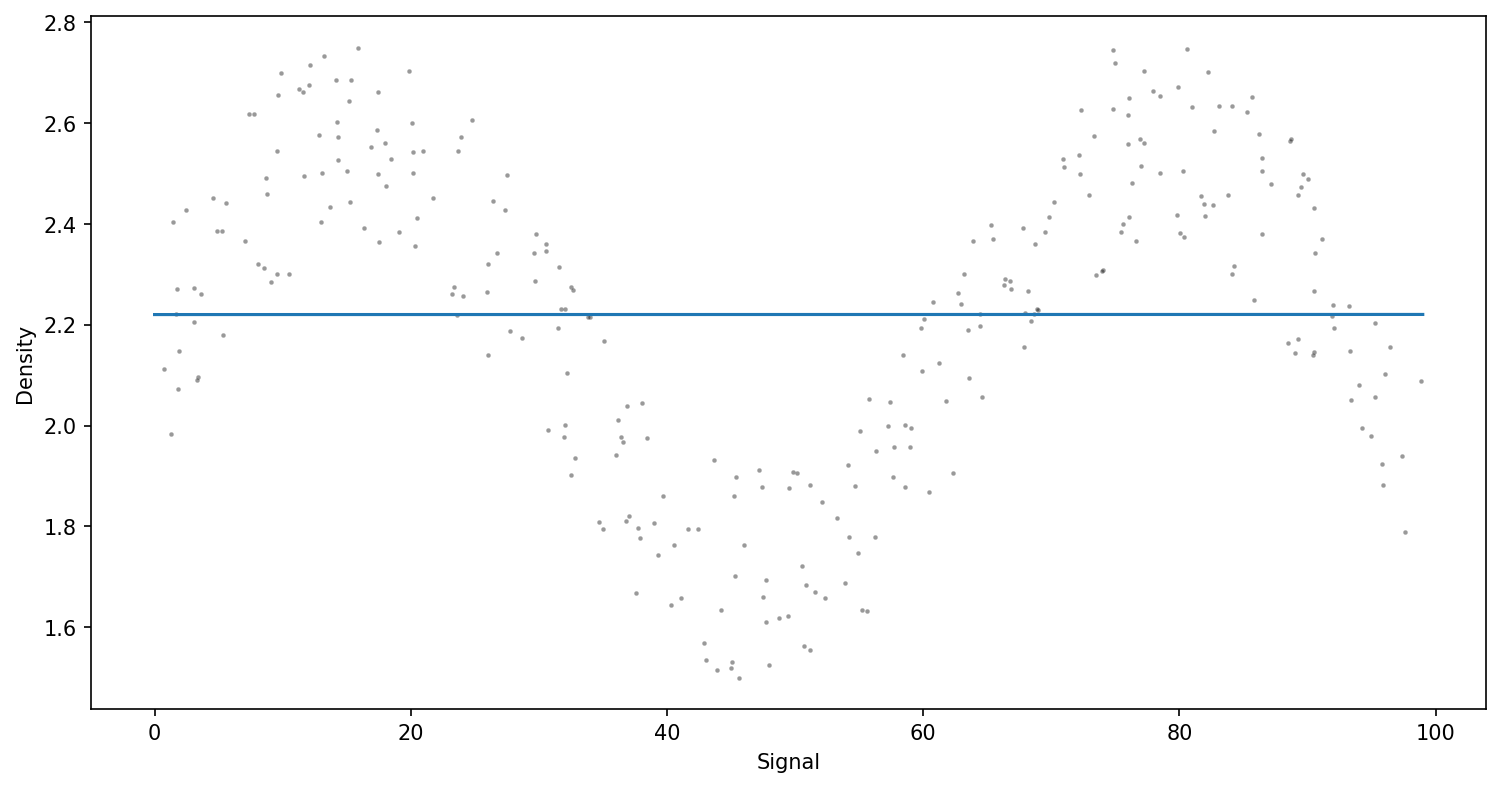

In [25]:
model=LinearRegression()
run_model(model,X_train,y_train,X_test,y_test)

In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

In [27]:
pipe=make_pipeline(PolynomialFeatures(degree=2),LinearRegression())

MAE: 0.22903105443511335
RMSE: 0.2817309563725596


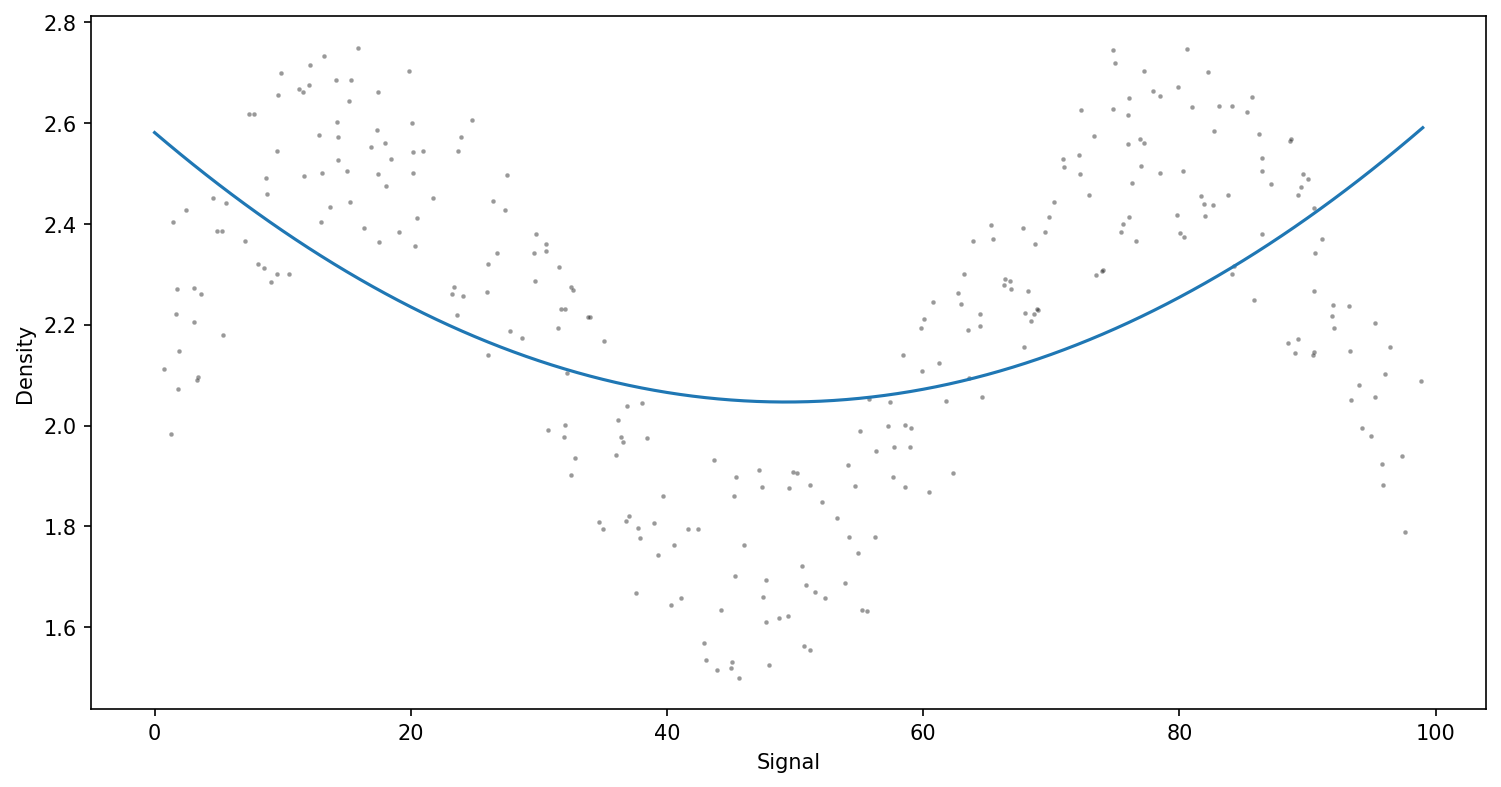

In [28]:
run_model(pipe,X_train,y_train,X_test,y_test)

In [29]:
pipe10=make_pipeline(PolynomialFeatures(degree=10),LinearRegression())

MAE: 0.1433857719391462
RMSE: 0.16269005292854596


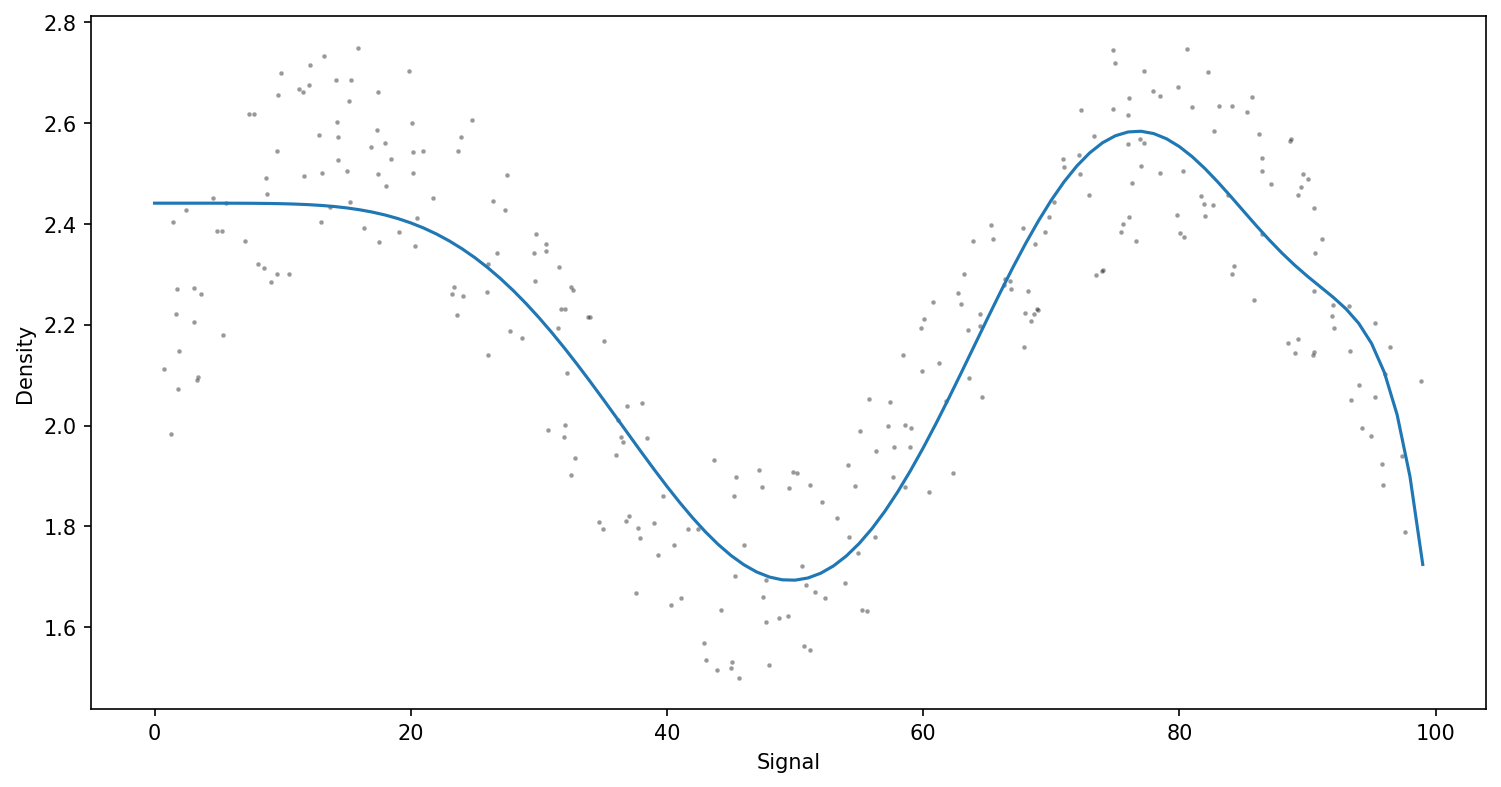

In [30]:
run_model(pipe10,X_train,y_train,X_test,y_test)

In [31]:
pipe3=make_pipeline(PolynomialFeatures(degree=3),LinearRegression())

MAE: 0.2421183403953149
RMSE: 0.287974812791889


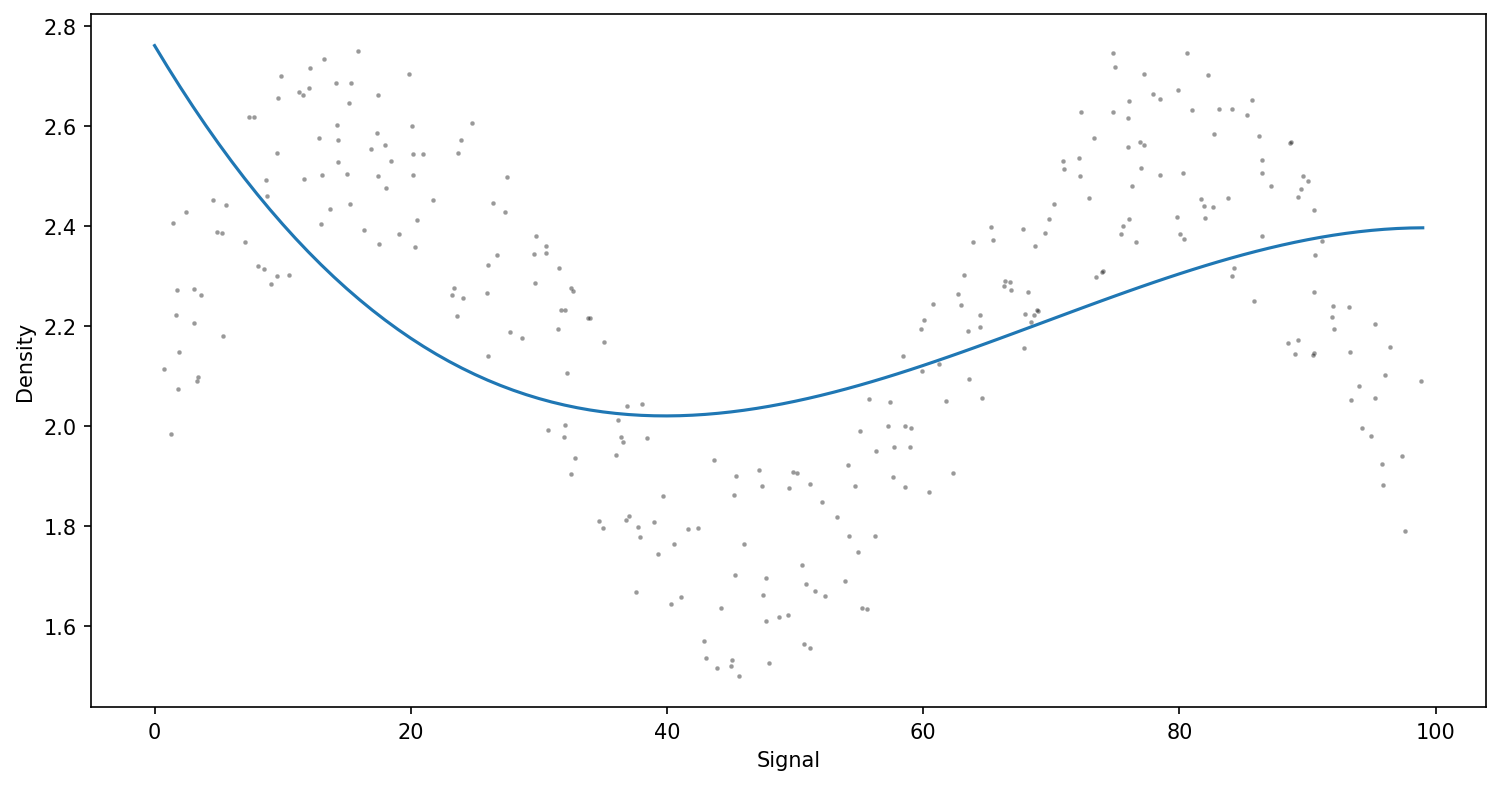

In [32]:
run_model(pipe3,X_train,y_train,X_test,y_test)

Three degrees polynomial seems too little. Let's try the double.

In [33]:
pipe6=make_pipeline(PolynomialFeatures(degree=6),LinearRegression())

MAE: 0.11969168049270058
RMSE: 0.13807520083403252


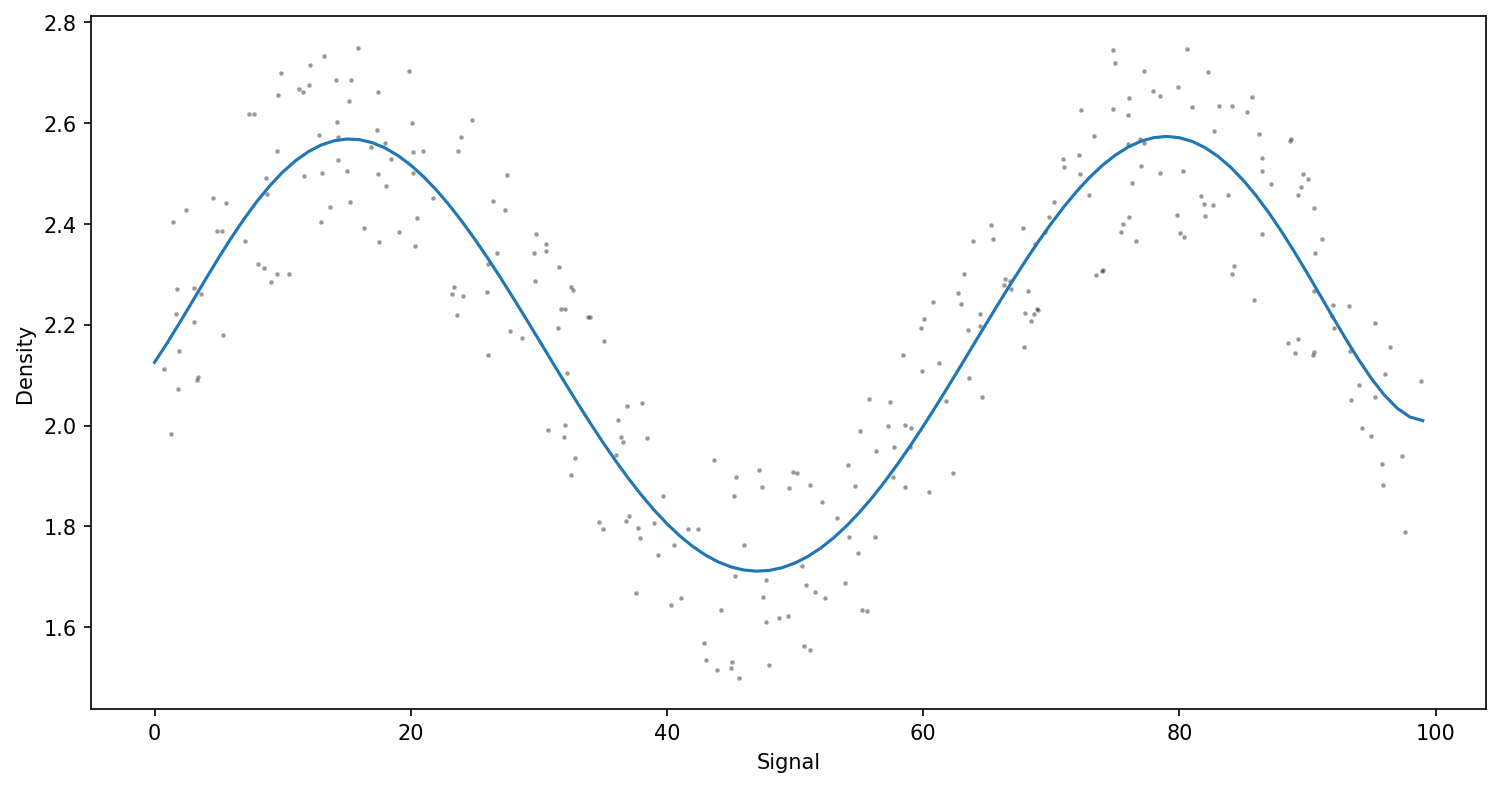

In [34]:
run_model(pipe6,X_train,y_train,X_test,y_test)

In [35]:
pipe50=make_pipeline(PolynomialFeatures(degree=50),LinearRegression())

MAE: 0.1952185639118398
RMSE: 0.24893686327122844


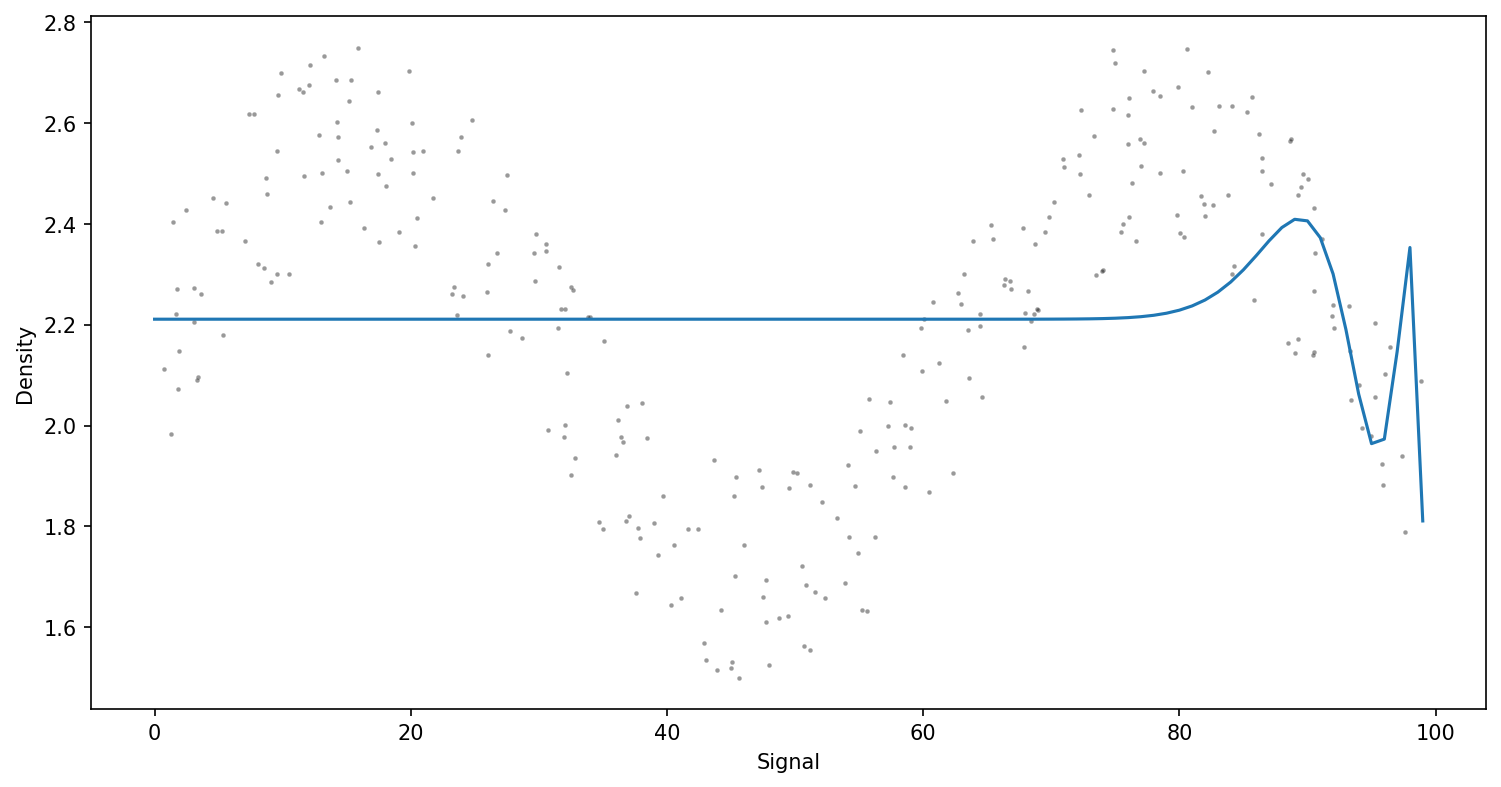

In [36]:
run_model(pipe50,X_train,y_train,X_test,y_test)

In [37]:
pipe25=make_pipeline(PolynomialFeatures(degree=25),LinearRegression())

MAE: 0.20988580781961985
RMSE: 0.25685821180907753


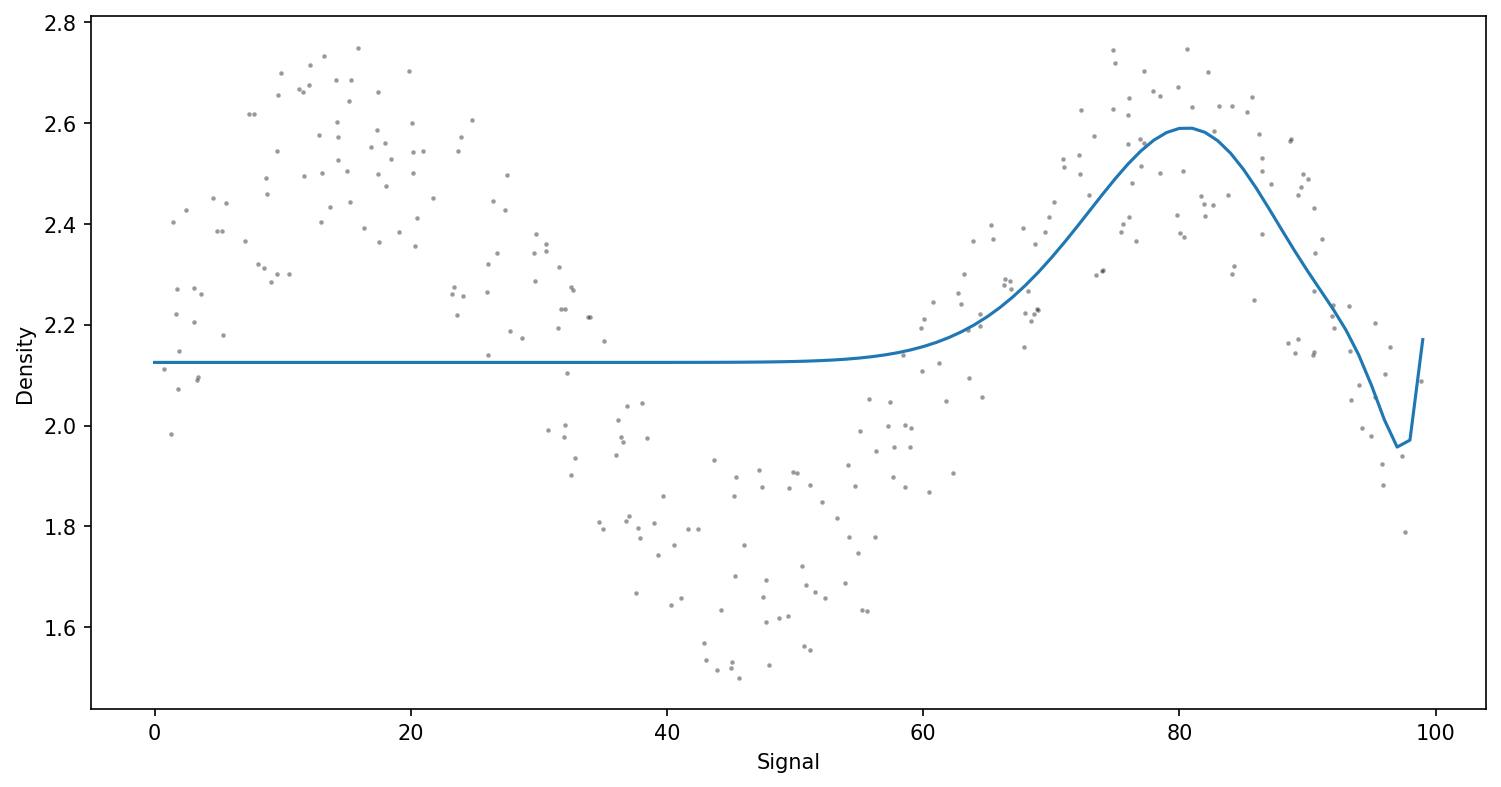

In [38]:
run_model(pipe25,X_train,y_train,X_test,y_test)

MAE: 0.20769800884608297
RMSE: 0.23993961037172784


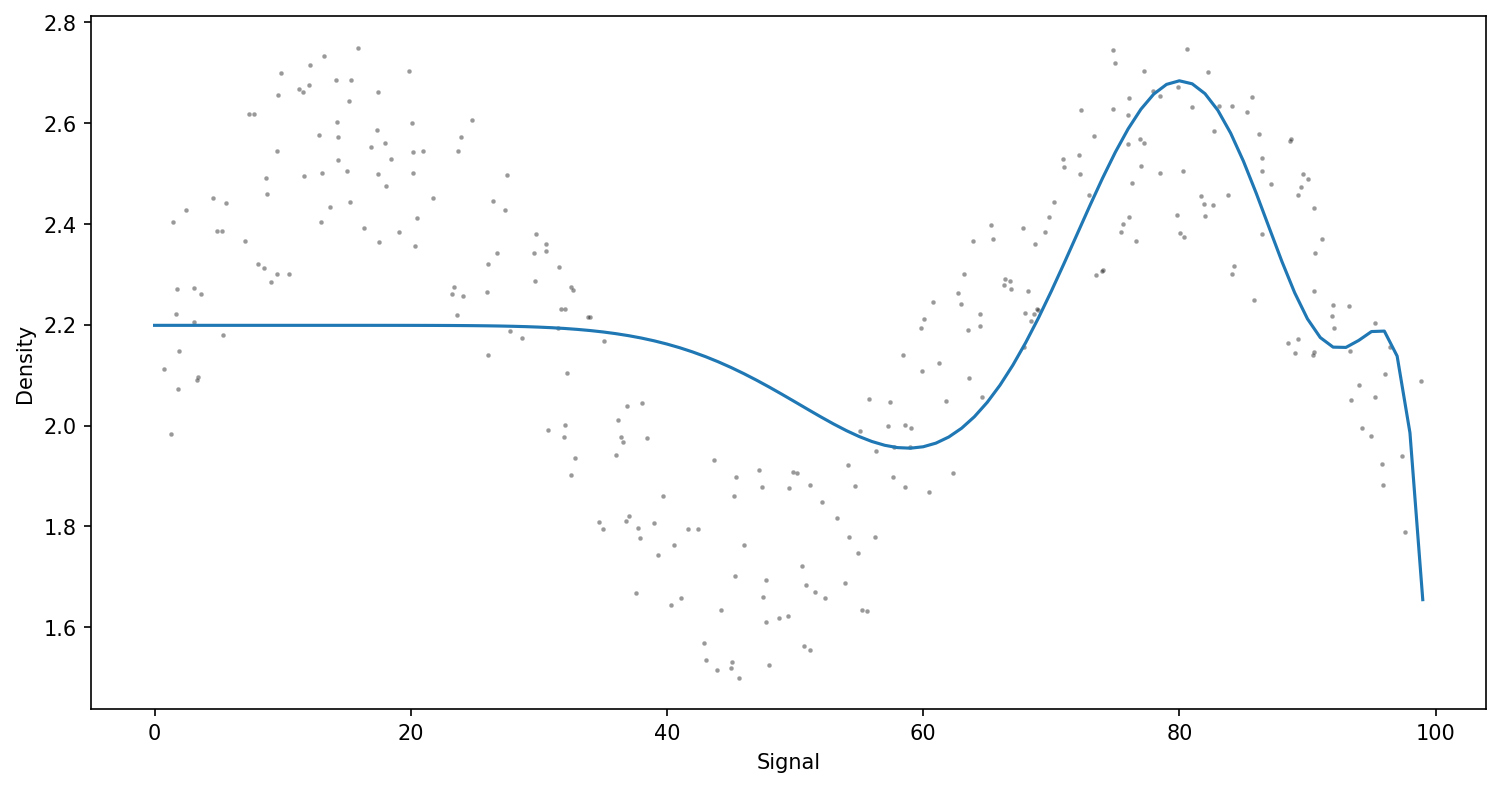

In [39]:
pipe15=make_pipeline(PolynomialFeatures(degree=15),LinearRegression())
run_model(pipe15,X_train,y_train,X_test,y_test)

In [40]:
from sklearn.neighbors import KNeighborsRegressor

MAE: 0.11877297474442378
RMSE: 0.1523487028635337
MAE: 0.12198383614100558
RMSE: 0.13730685016923647
MAE: 0.11635971693292672
RMSE: 0.13277855732740926
MAE: 0.13363165935705318
RMSE: 0.15954234753677107


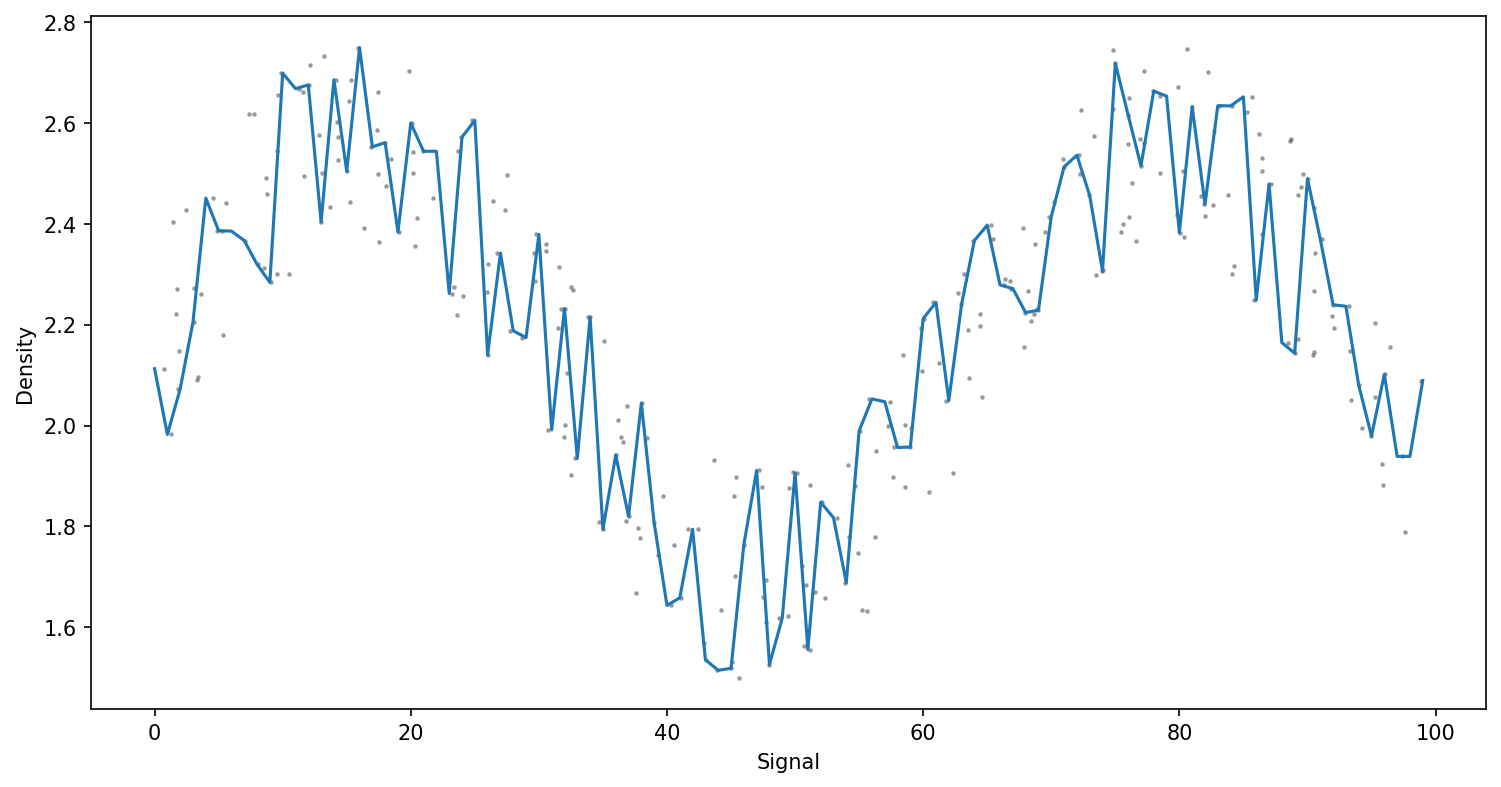

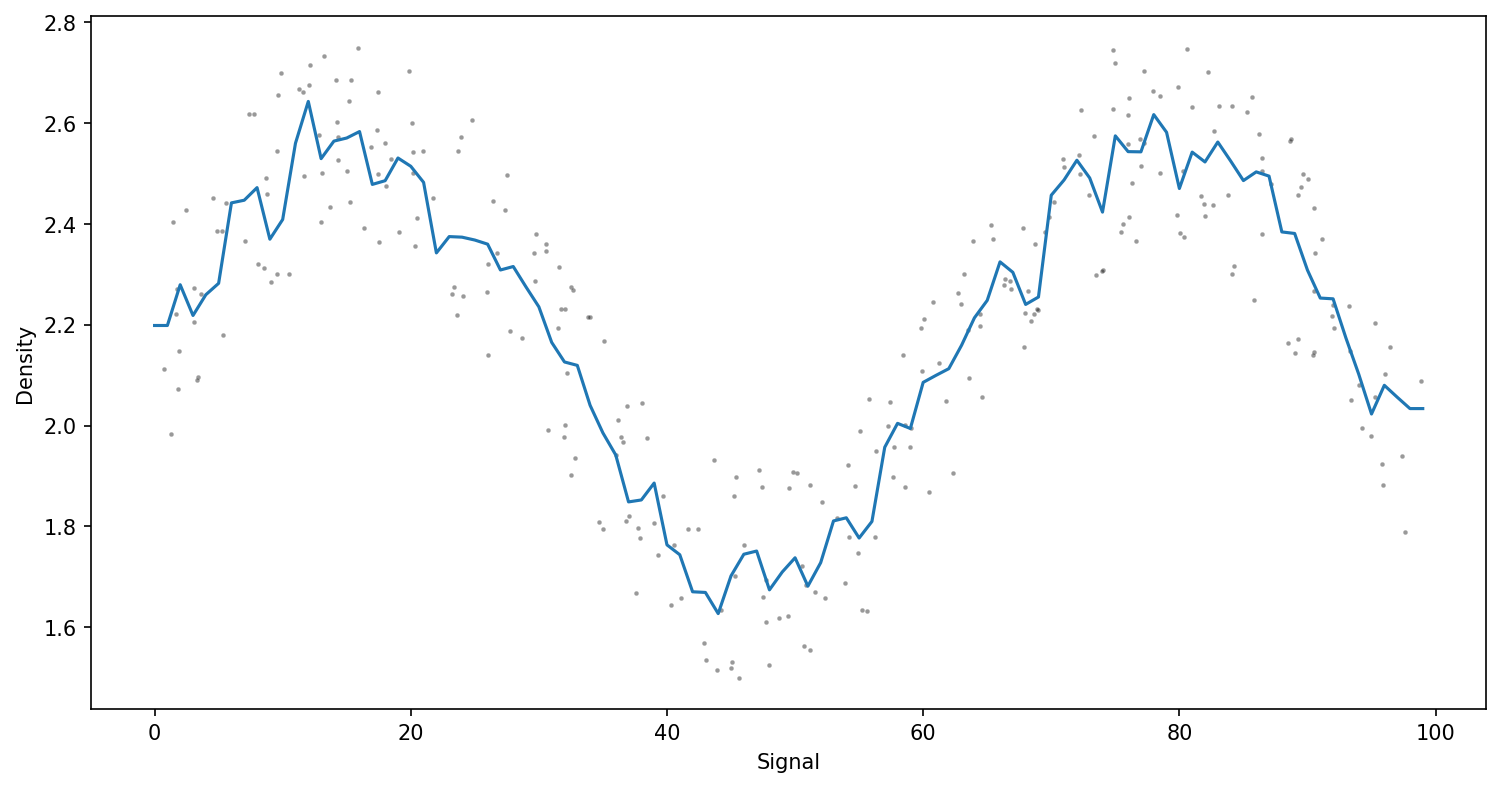

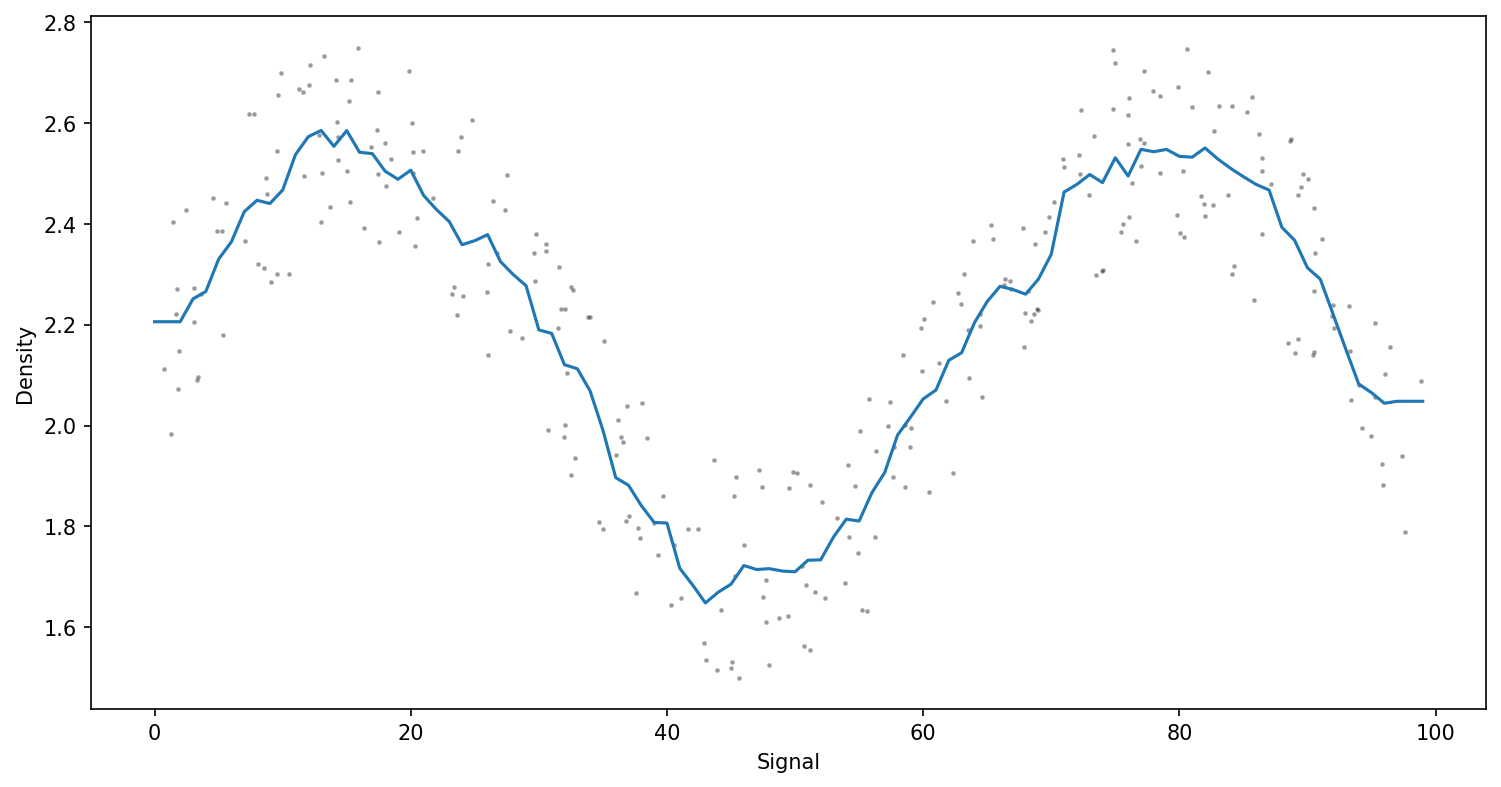

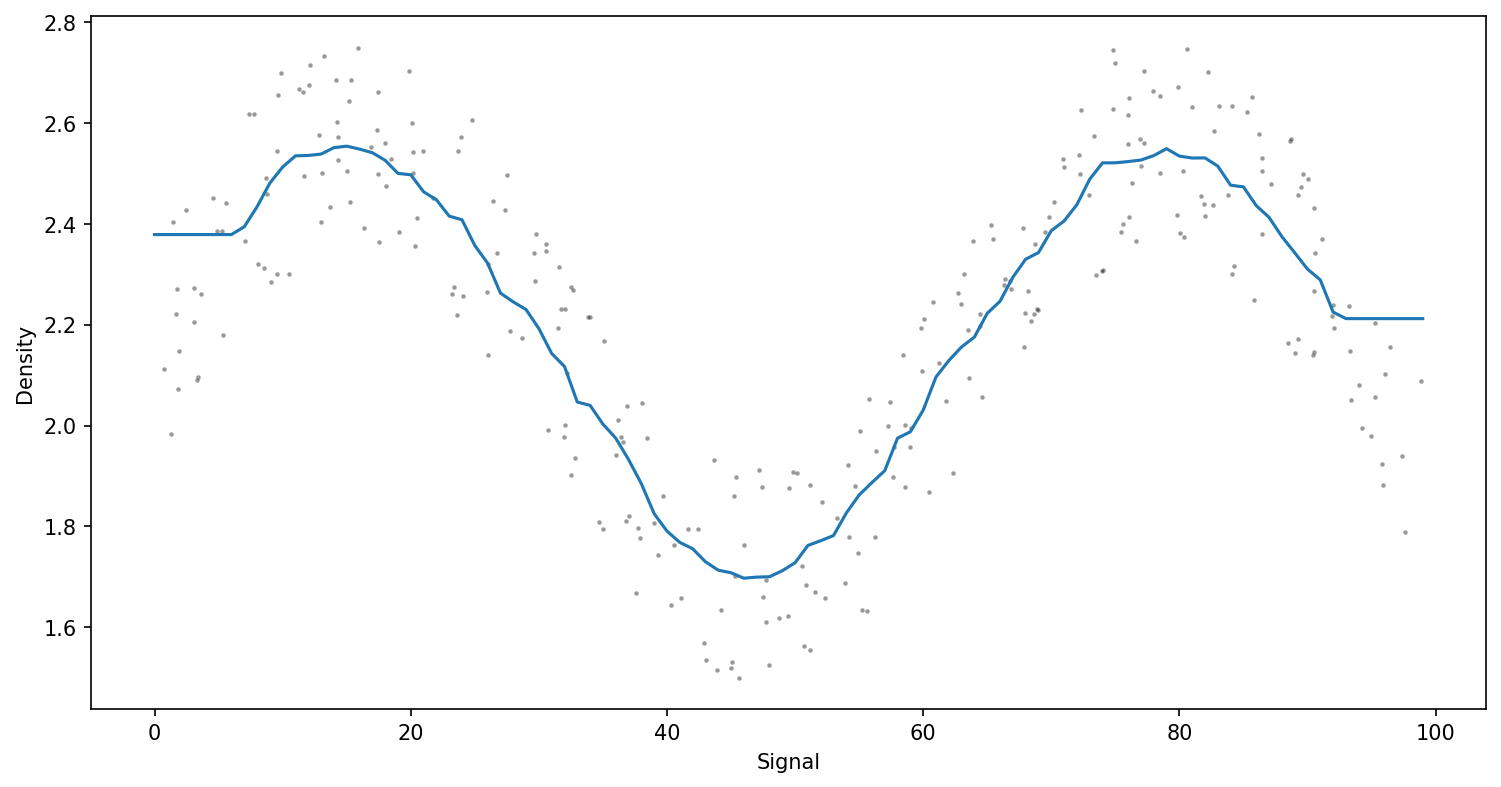

In [41]:
k_values = [1,5,10,30]
for n in k_values:
    kmodel=KNeighborsRegressor(n_neighbors=n)
    run_model(kmodel,X_train,y_train,X_test,y_test)

In [42]:
from sklearn.tree import DecisionTreeRegressor

MAE: 0.11877297474442378
RMSE: 0.1523487028635337


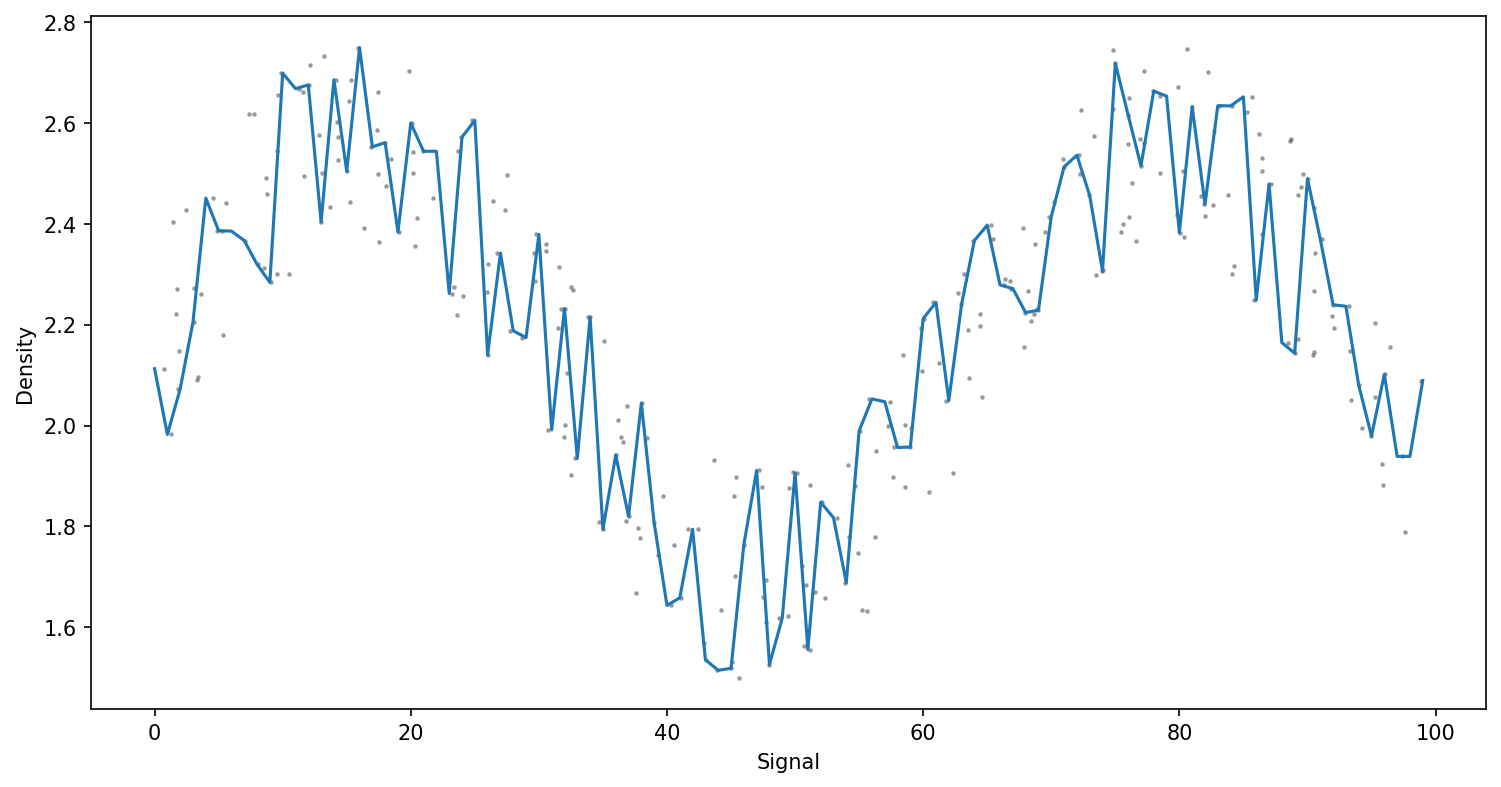

In [43]:
dtmodel=DecisionTreeRegressor()
run_model(dtmodel,X_train,y_train,X_test,y_test)

In [44]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

In [45]:
svr=SVR()
param_grid={'C':[0.01,0.1,1,5,10,100,1000],'gamma':['auto','scale']}
grid=GridSearchCV(svr,param_grid)

MAE: 0.10854210121348368
RMSE: 0.12646999302046696


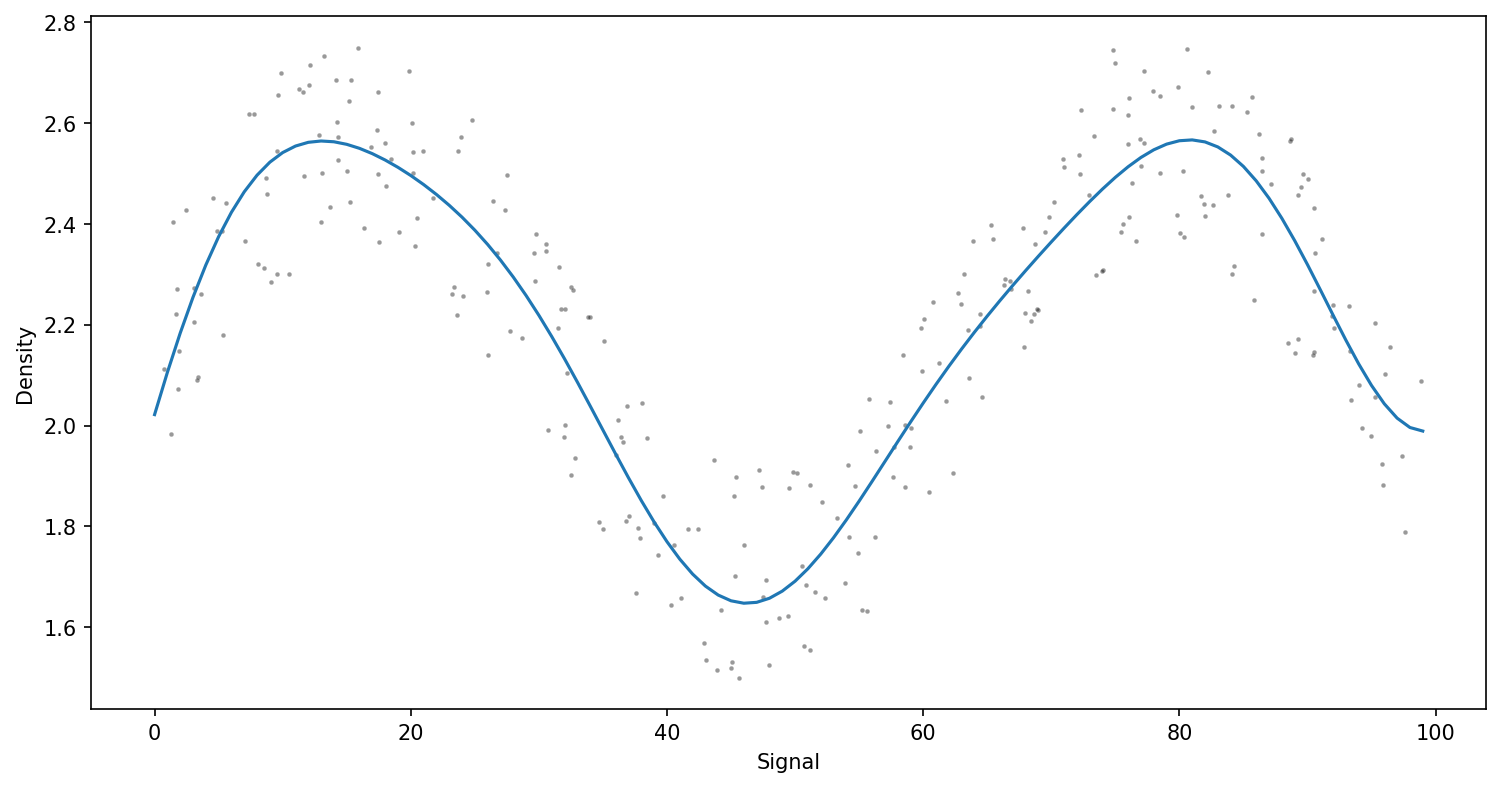

In [46]:
run_model(grid,X_train,y_train,X_test,y_test)

In [47]:
from sklearn.ensemble import RandomForestRegressor

In [48]:
rfr=RandomForestRegressor(n_estimators=10)

MAE: 0.11351733963457614
RMSE: 0.13749031700566897


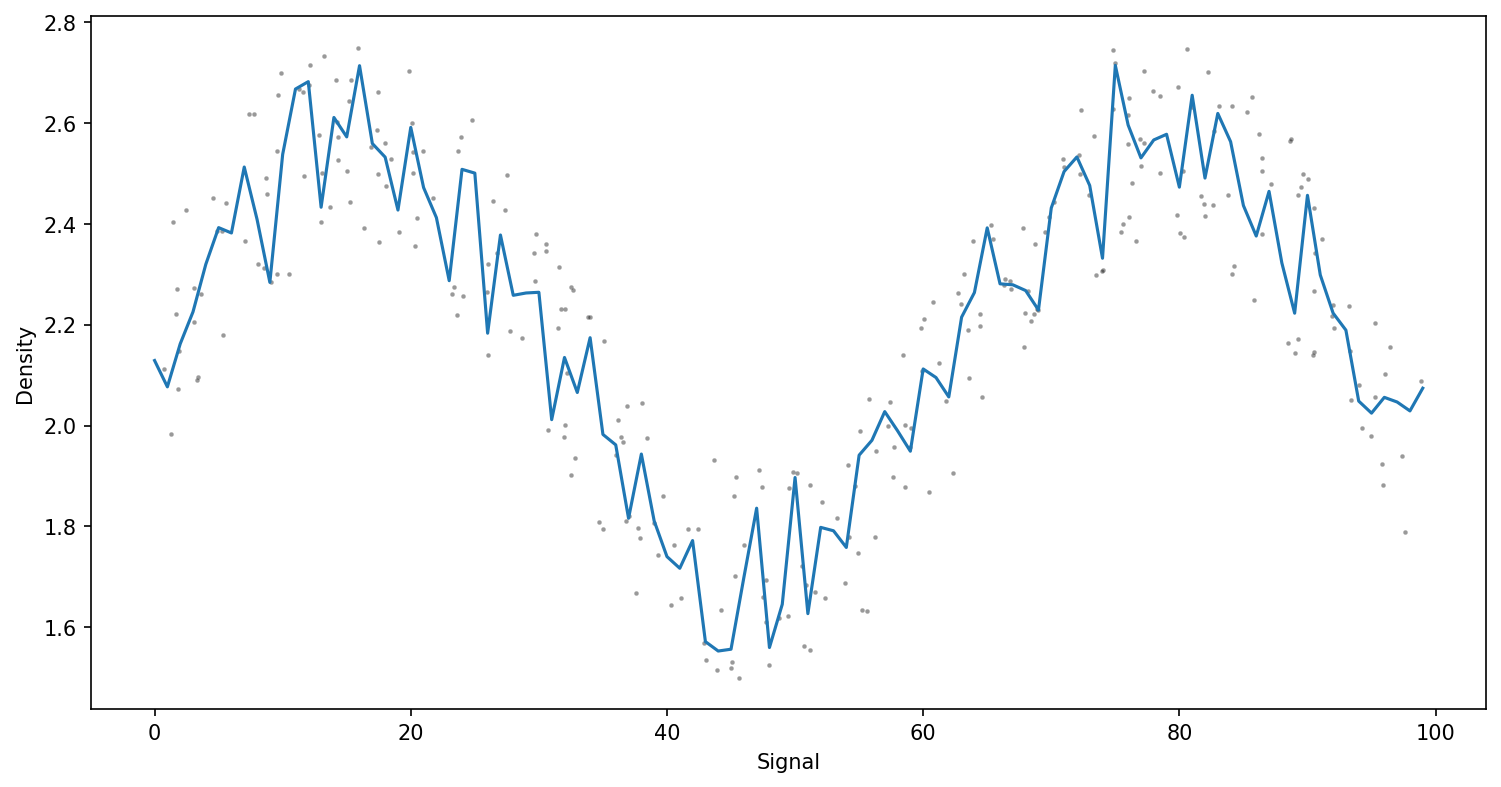

In [49]:
run_model(rfr,X_train,y_train,X_test,y_test)

## Let's also explore the behaviour of boosting techniques for random forests

In [50]:
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor

MAE: 0.11318284854800689
RMSE: 0.13294148649584667


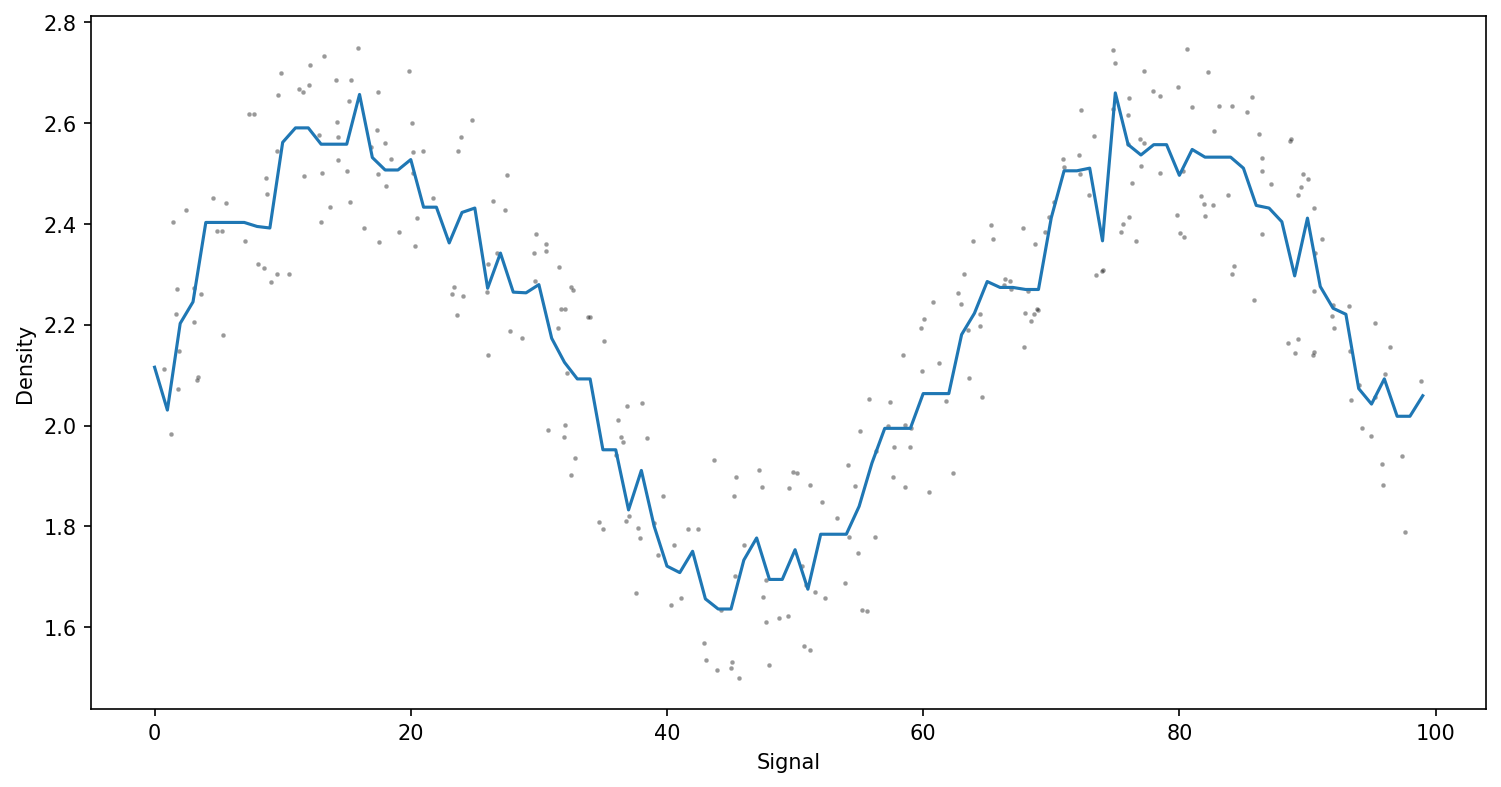

In [51]:
gbmodel=GradientBoostingRegressor()
run_model(gbmodel,X_train,y_train,X_test,y_test)

MAE: 0.12497535040048431
RMSE: 0.1435930679186959


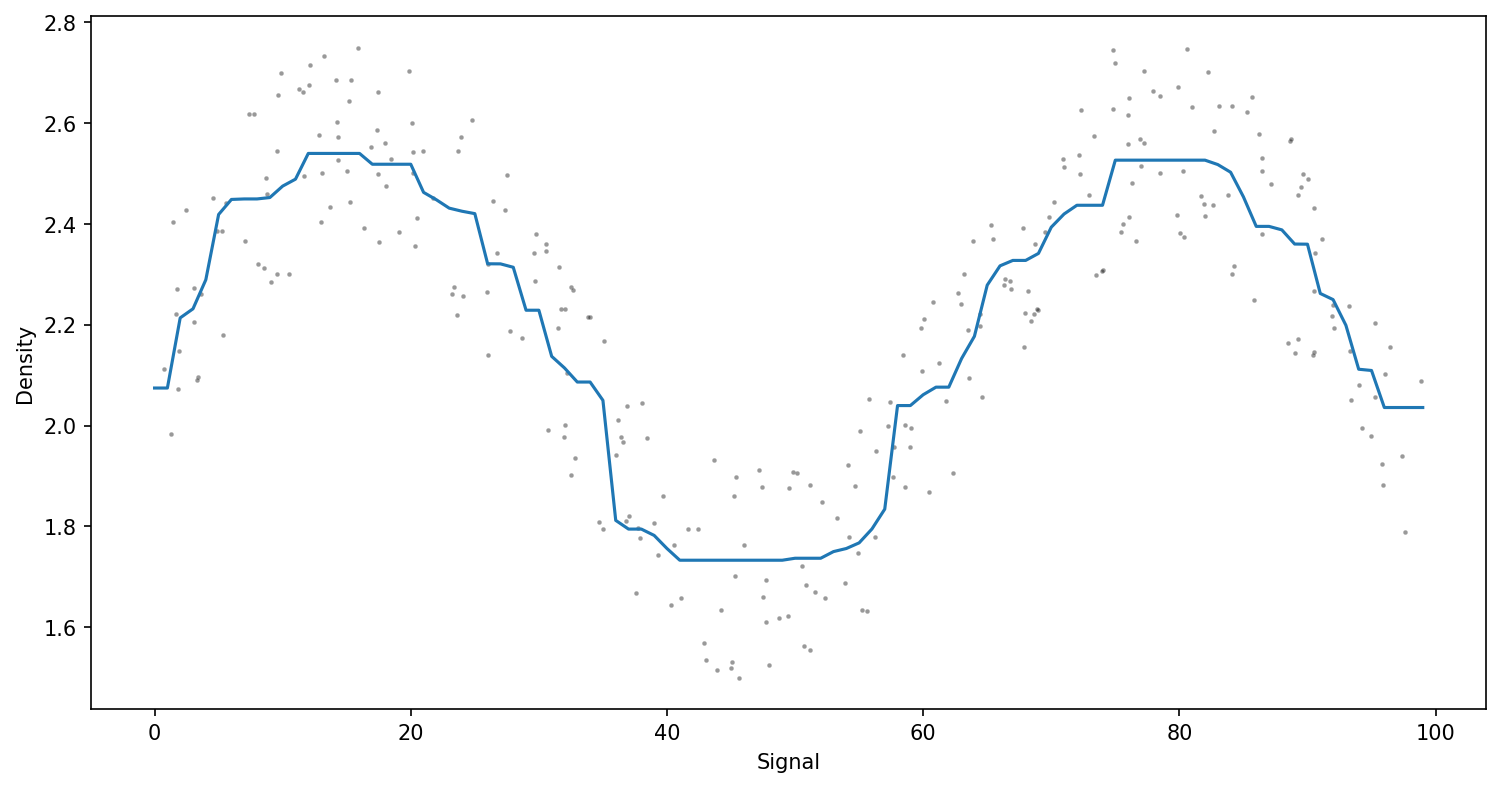

In [52]:
abmodel=AdaBoostRegressor()
run_model(abmodel,X_train,y_train,X_test,y_test)

Boosting is a meta-learning algorithm that can be applied to any learning method, it is not in itself a learning method but an algorithm where you can insert any learing algorithm.

But Random Forests are particularly suitable to use it.

The theory in boosting is more or less answering the question: "Can we combine a set of simple/weak learners with some coefficients to form an ensemble learner that acts as a much better learner?"

# Adaptive Boosting: Adaboost

In [53]:
df=pd.read_csv('../../jupyter_notebooks/DATA/mushrooms.csv')
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [58]:
df.describe().transpose()

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


Specification of the features:  https://archive.ics.uci.edu/ml/datasets/Mushroom

<Axes: xlabel='class', ylabel='count'>

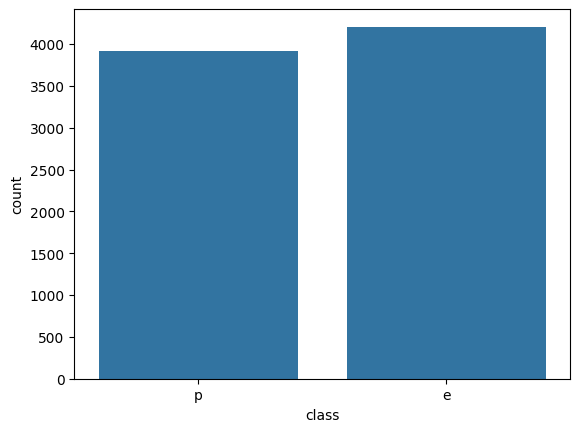

In [59]:
sns.countplot(data=df,x='class')

In [60]:
df.describe().transpose().reset_index().sort_values('unique')

,index,count,unique,top,freq
16,veil-type,8124,1,p,8124
0,class,8124,2,e,4208
4,bruises,8124,2,f,4748
6,gill-attachment,8124,2,f,7914
7,gill-spacing,8124,2,c,6812
8,gill-size,8124,2,b,5612
10,stalk-shape,8124,2,t,4608
18,ring-number,8124,3,o,7488
2,cap-surface,8124,4,y,3244
17,veil-color,8124,4,w,7924


In [61]:
unique_features=df.describe().transpose().reset_index().sort_values('unique')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, 'veil-type'),
  Text(1, 0, 'class'),
  Text(2, 0, 'bruises'),
  Text(3, 0, 'gill-attachment'),
  Text(4, 0, 'gill-spacing'),
  Text(5, 0, 'gill-size'),
  Text(6, 0, 'stalk-shape'),
  Text(7, 0, 'ring-number'),
  Text(8, 0, 'cap-surface'),
  Text(9, 0, 'veil-color'),
  Text(10, 0, 'stalk-surface-below-ring'),
  Text(11, 0, 'stalk-surface-above-ring'),
  Text(12, 0, 'ring-type'),
  Text(13, 0, 'stalk-root'),
  Text(14, 0, 'cap-shape'),
  Text(15, 0, 'population'),
  Text(16, 0, 'habitat'),
  Text(17, 0, 'stalk-color-above-ring'),
  Text(18, 0, 'stalk-color-below-ring'),
  Text(19, 0, 'odor'),
  Text(20, 0, 'spore-print-color'),
  Text(21, 0, 'cap-color'),
  Text(22, 0, 'gill-color')])

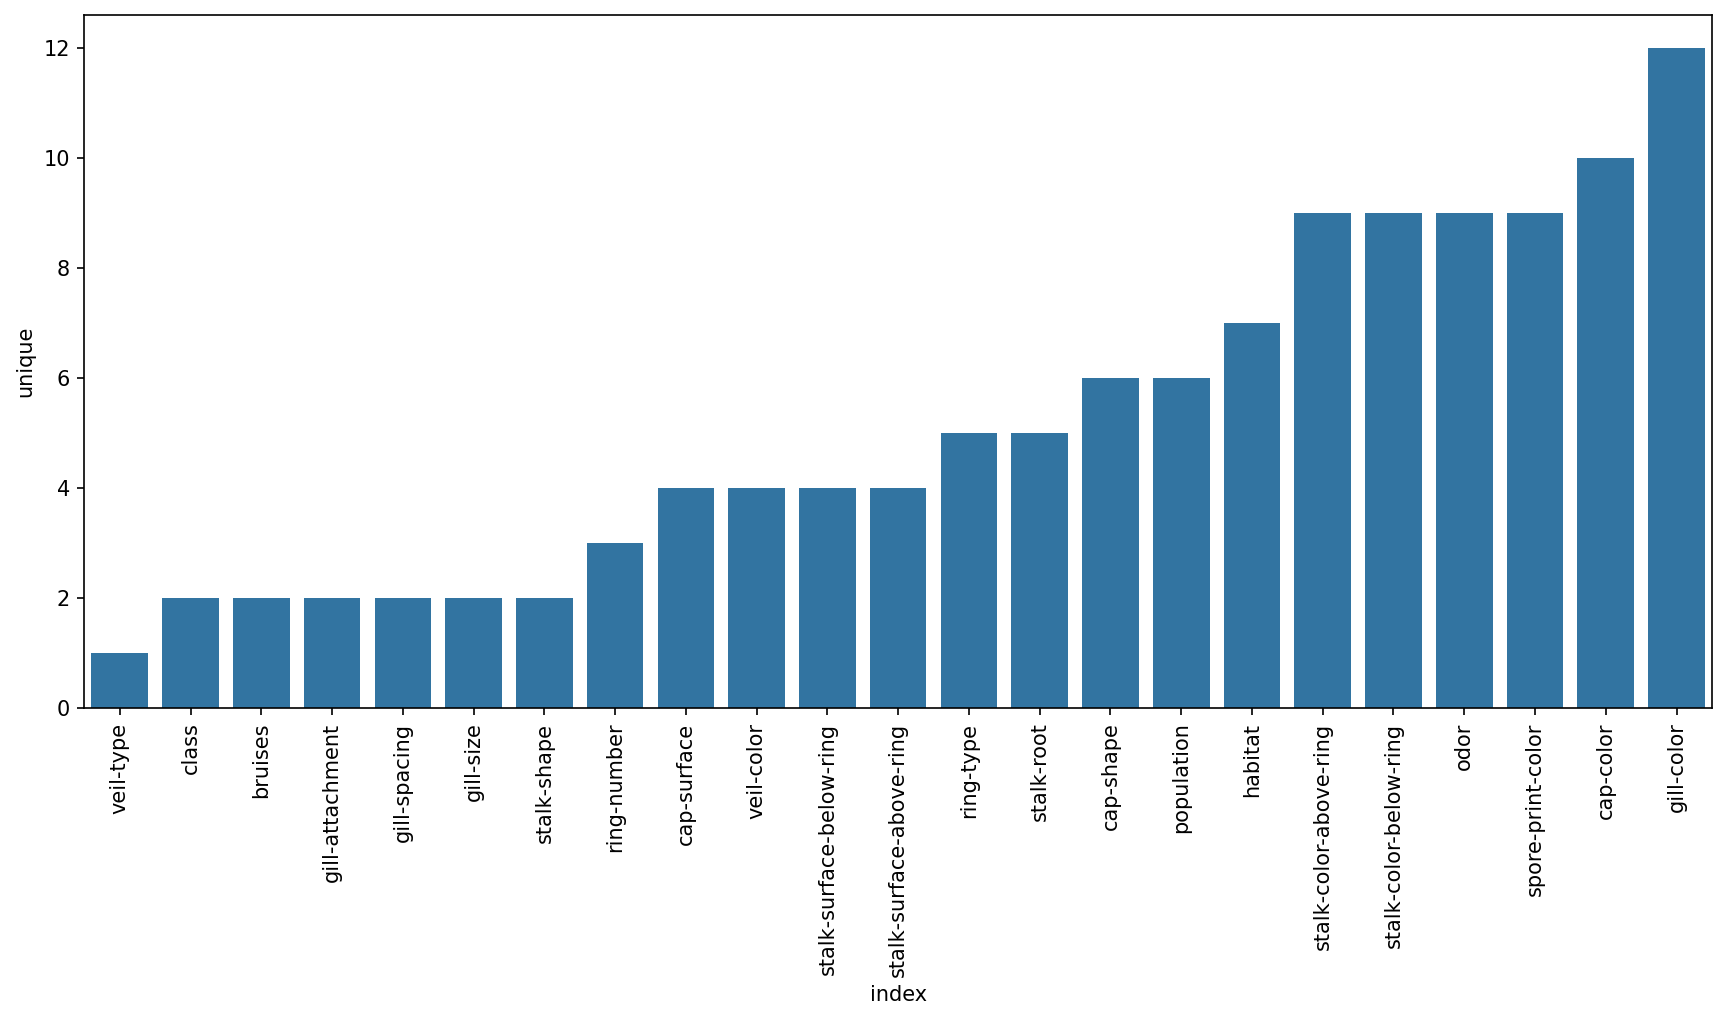

In [63]:
plt.figure(figsize=(14,6),dpi=150)
sns.barplot(data=unique_features,x='index',y='unique')
plt.xticks(rotation=90)

In [64]:
X=df.drop('class',axis=1)

In [65]:
X=pd.get_dummies(X,drop_first=True)

In [66]:
X

,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,True,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
8120,False,False,False,False,True,False,True,False,False,False,...,False,False,True,False,False,True,False,False,False,False
8121,False,True,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
8122,False,False,True,False,False,False,False,True,False,False,...,False,False,True,False,False,True,False,False,False,False


In [67]:
y=df['class']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=101)

In [70]:
from sklearn.ensemble import AdaBoostClassifier

In [71]:
model=AdaBoostClassifier(n_estimators=1)

In [72]:
model.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",1
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [73]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay,accuracy_score

In [74]:
predictions=model.predict(X_test)

In [76]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           e       0.96      0.81      0.88       655
           p       0.81      0.96      0.88       564

    accuracy                           0.88      1219
   macro avg       0.88      0.88      0.88      1219
weighted avg       0.89      0.88      0.88      1219



In [77]:
model.feature_importances_

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [78]:
model.feature_importances_.argmax()

np.int64(22)

In [79]:
X.columns[22]

'odor_n'

<Axes: xlabel='odor', ylabel='count'>

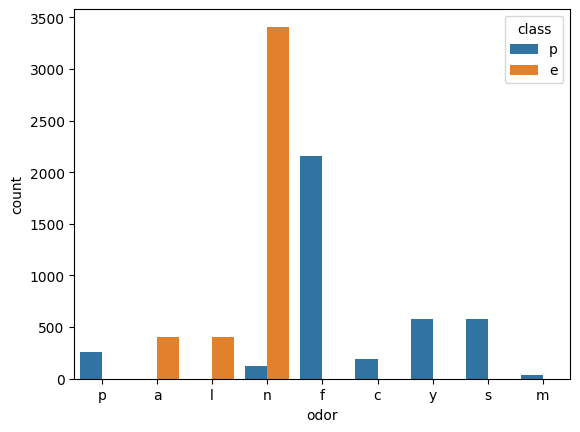

In [81]:
sns.countplot(data=df,x='odor',hue='class')

In [82]:
# see how many features I can check that still add information to the model.

error_rates=[]
for n in range(1,96):
    model=AdaBoostClassifier(n_estimators=n)
    model.fit(X_train,y_train)
    preds=model.predict(X_test)
    err=1-accuracy_score(y_test,preds)
    error_rates.append(err)

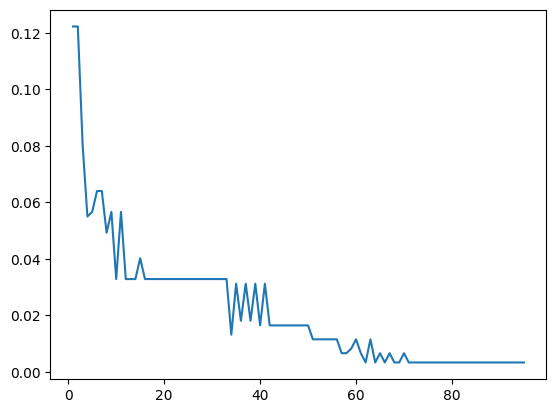

In [83]:
plt.plot(range(1,96),error_rates)

In [84]:
model.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.08758134, 0.15483051,
       0.03297374, 0.        , 0.07596867, 0.08553577, 0.        ,
       0.        , 0.        , 0.01449336, 0.04761456, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.02261282, 0.        , 0.01960917, 0.        , 0.        ,
       0.04145947, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.03716765, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.02345876, 0.        , 0.     

In [86]:
feats=pd.DataFrame(index=X.columns,data=model.feature_importances_,columns=['Importance'])
feats

,Importance
cap-shape_c,0.000000
cap-shape_f,0.000000
cap-shape_k,0.000000
cap-shape_s,0.000000
cap-shape_x,0.000000
...,...
habitat_l,0.000000
habitat_m,0.000000
habitat_p,0.000000
habitat_u,0.000000


### Too many are 0, so too many do not contribute to the separation of the classes

In [88]:
imp_feats=feats[feats['Importance']>0]
imp_feats

,Importance
odor_c,0.087581
odor_f,0.154831
odor_l,0.032974
odor_n,0.075969
odor_p,0.085536
gill-spacing_w,0.014493
gill-size_n,0.047615
stalk-shape_t,0.022613
stalk-root_c,0.019609
stalk-surface-above-ring_k,0.041459


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'odor_c'),
  Text(1, 0, 'odor_f'),
  Text(2, 0, 'odor_l'),
  Text(3, 0, 'odor_n'),
  Text(4, 0, 'odor_p'),
  Text(5, 0, 'gill-spacing_w'),
  Text(6, 0, 'gill-size_n'),
  Text(7, 0, 'stalk-shape_t'),
  Text(8, 0, 'stalk-root_c'),
  Text(9, 0, 'stalk-surface-above-ring_k'),
  Text(10, 0, 'stalk-color-below-ring_n'),
  Text(11, 0, 'ring-type_f'),
  Text(12, 0, 'ring-type_p'),
  Text(13, 0, 'spore-print-color_n'),
  Text(14, 0, 'spore-print-color_r'),
  Text(15, 0, 'spore-print-color_u'),
  Text(16, 0, 'spore-print-color_w'),
  Text(17, 0, 'population_c'),
  Text(18, 0, 'population_v'),
  Text(19, 0, 'habitat_w')])

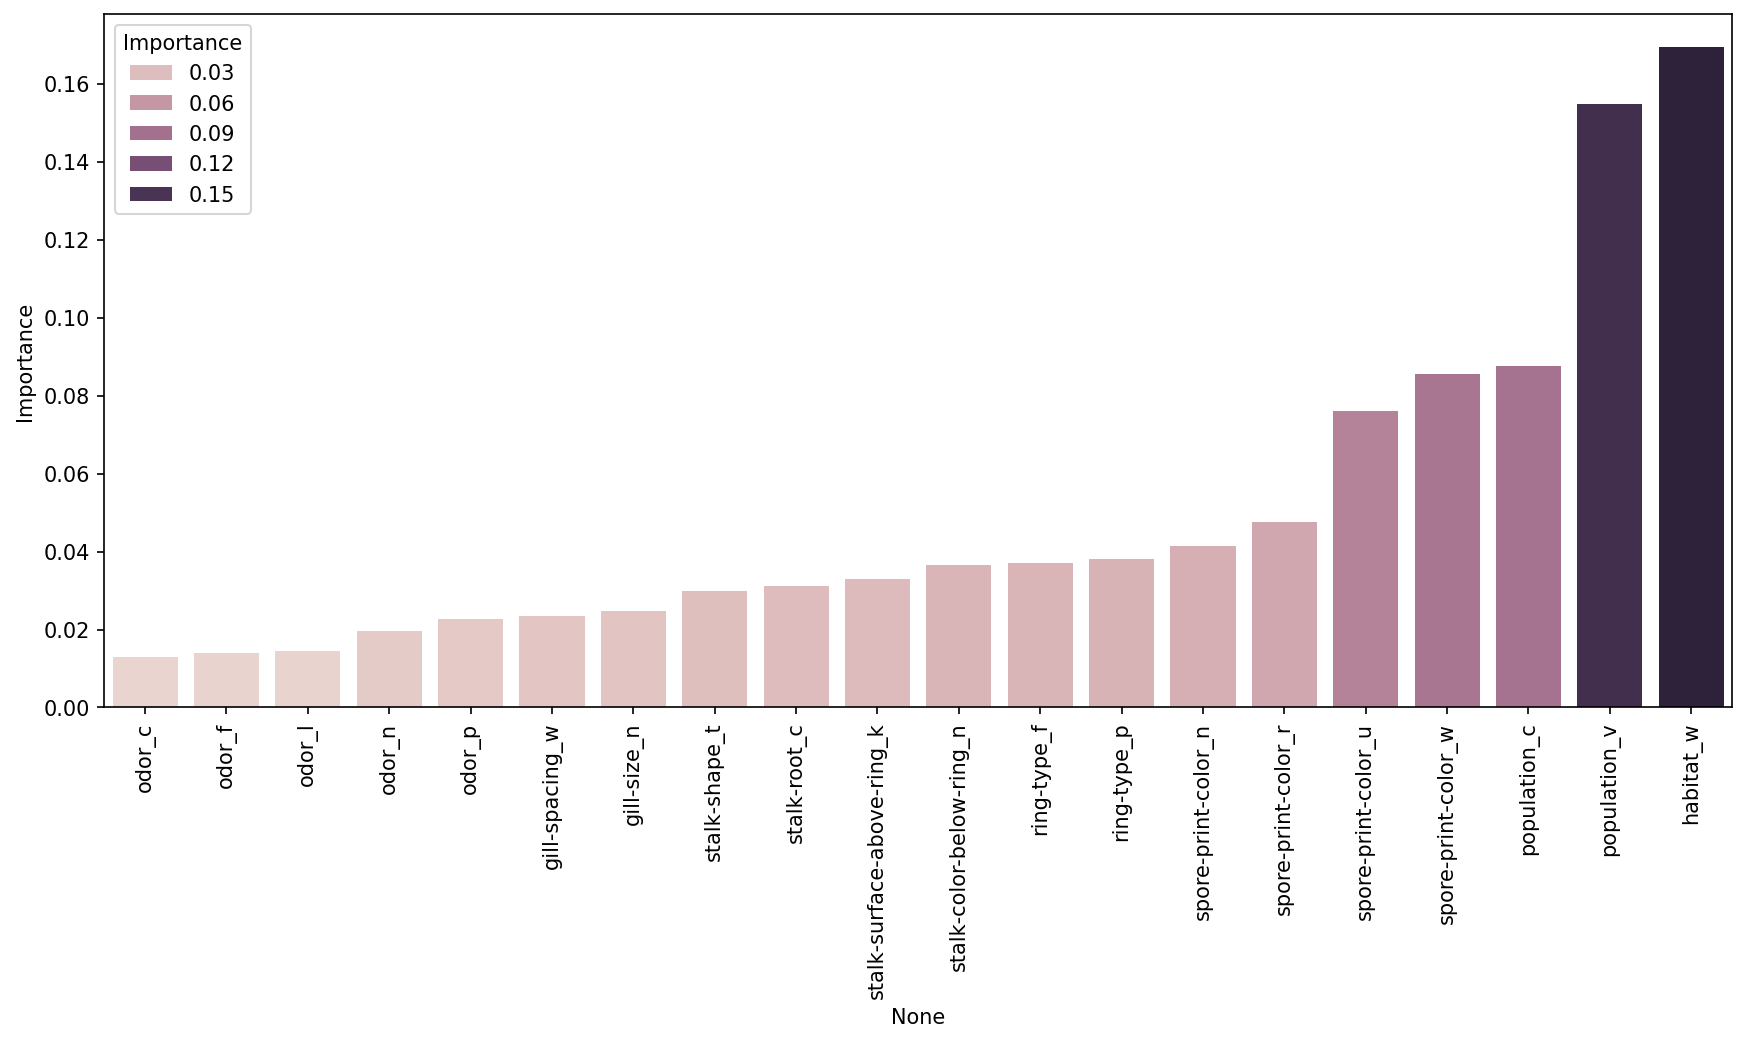

In [91]:
plt.figure(figsize=(14,6),dpi=150)
sns.barplot(data=imp_feats.sort_values('Importance'),x=imp_feats.index,y='Importance',hue='Importance')
plt.xticks(rotation=90)

# Gradient Boosting

In [92]:
X=df.drop('class',axis=1)

In [94]:
X=pd.get_dummies(X,drop_first=True)

In [95]:
y=df['class']

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=101)

In [98]:
from sklearn.ensemble import GradientBoostingClassifier

In [99]:
from sklearn.model_selection import GridSearchCV

In [100]:
param_grid={'n_estimators':[50,100],'learning_rate':[0.1,0.05,0.2],'max_depth':[3,4,5]}

In [101]:
gb_model=GradientBoostingClassifier()

In [102]:
grid=GridSearchCV(gb_model,param_grid)

In [103]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

In [104]:
predictions=grid.predict(X_test)
predictions

array(['p', 'e', 'p', ..., 'p', 'p', 'e'], shape=(1219,), dtype=object)

In [106]:
# as it turns out, the best parameters are the default ones.
grid.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

In [107]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       655
           p       1.00      1.00      1.00       564

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219



In [109]:
grid.best_estimator_.feature_importances_

array([2.91150176e-04, 1.41723949e-16, 0.00000000e+00, 0.00000000e+00,
       4.28069607e-17, 1.04524302e-03, 3.01735102e-17, 5.06011038e-06,
       0.00000000e+00, 0.00000000e+00, 1.99395508e-17, 0.00000000e+00,
       2.91701182e-17, 0.00000000e+00, 0.00000000e+00, 5.71685316e-07,
       2.31053911e-03, 5.29767058e-02, 6.24175887e-04, 1.02730970e-02,
       1.82499853e-02, 1.35665704e-05, 6.14744334e-01, 8.63939501e-03,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.25278108e-02,
       1.08448951e-02, 0.00000000e+00, 2.44660804e-16, 0.00000000e+00,
       1.06313623e-17, 0.00000000e+00, 0.00000000e+00, 2.42870818e-17,
       2.57358674e-18, 0.00000000e+00, 1.22817374e-17, 7.22134170e-18,
       6.17243983e-04, 6.78061940e-04, 1.35989845e-01, 0.00000000e+00,
       4.15866484e-02, 2.51047802e-03, 8.16239925e-04, 1.15245842e-04,
       3.60117275e-05, 8.16566353e-04, 2.48586049e-02, 1.18657130e-03,
       0.00000000e+00, 0.00000000e+00, 5.54948373e-04, 0.00000000e+00,
      

In [110]:
feat_import= grid.best_estimator_.feature_importances_

In [112]:
imp_feat=pd.DataFrame(index=X.columns,data=feat_import,columns=['Importance'])

In [113]:
imp_feat

,Importance
cap-shape_c,2.911502e-04
cap-shape_f,1.417239e-16
cap-shape_k,0.000000e+00
cap-shape_s,0.000000e+00
cap-shape_x,4.280696e-17
...,...
habitat_l,0.000000e+00
habitat_m,6.727232e-17
habitat_p,0.000000e+00
habitat_u,1.004851e-05


In [114]:
imp_feat=imp_feat[imp_feat['Importance']>0.0005]
imp_feat

,Importance
cap-surface_g,0.001045
cap-color_y,0.002311
bruises_t,0.052977
odor_c,0.000624
odor_f,0.010273
odor_l,0.018250
odor_n,0.614744
odor_p,0.008639
gill-spacing_w,0.012528
gill-size_n,0.010845


In [115]:
imp_feat=imp_feat.sort_values('Importance')

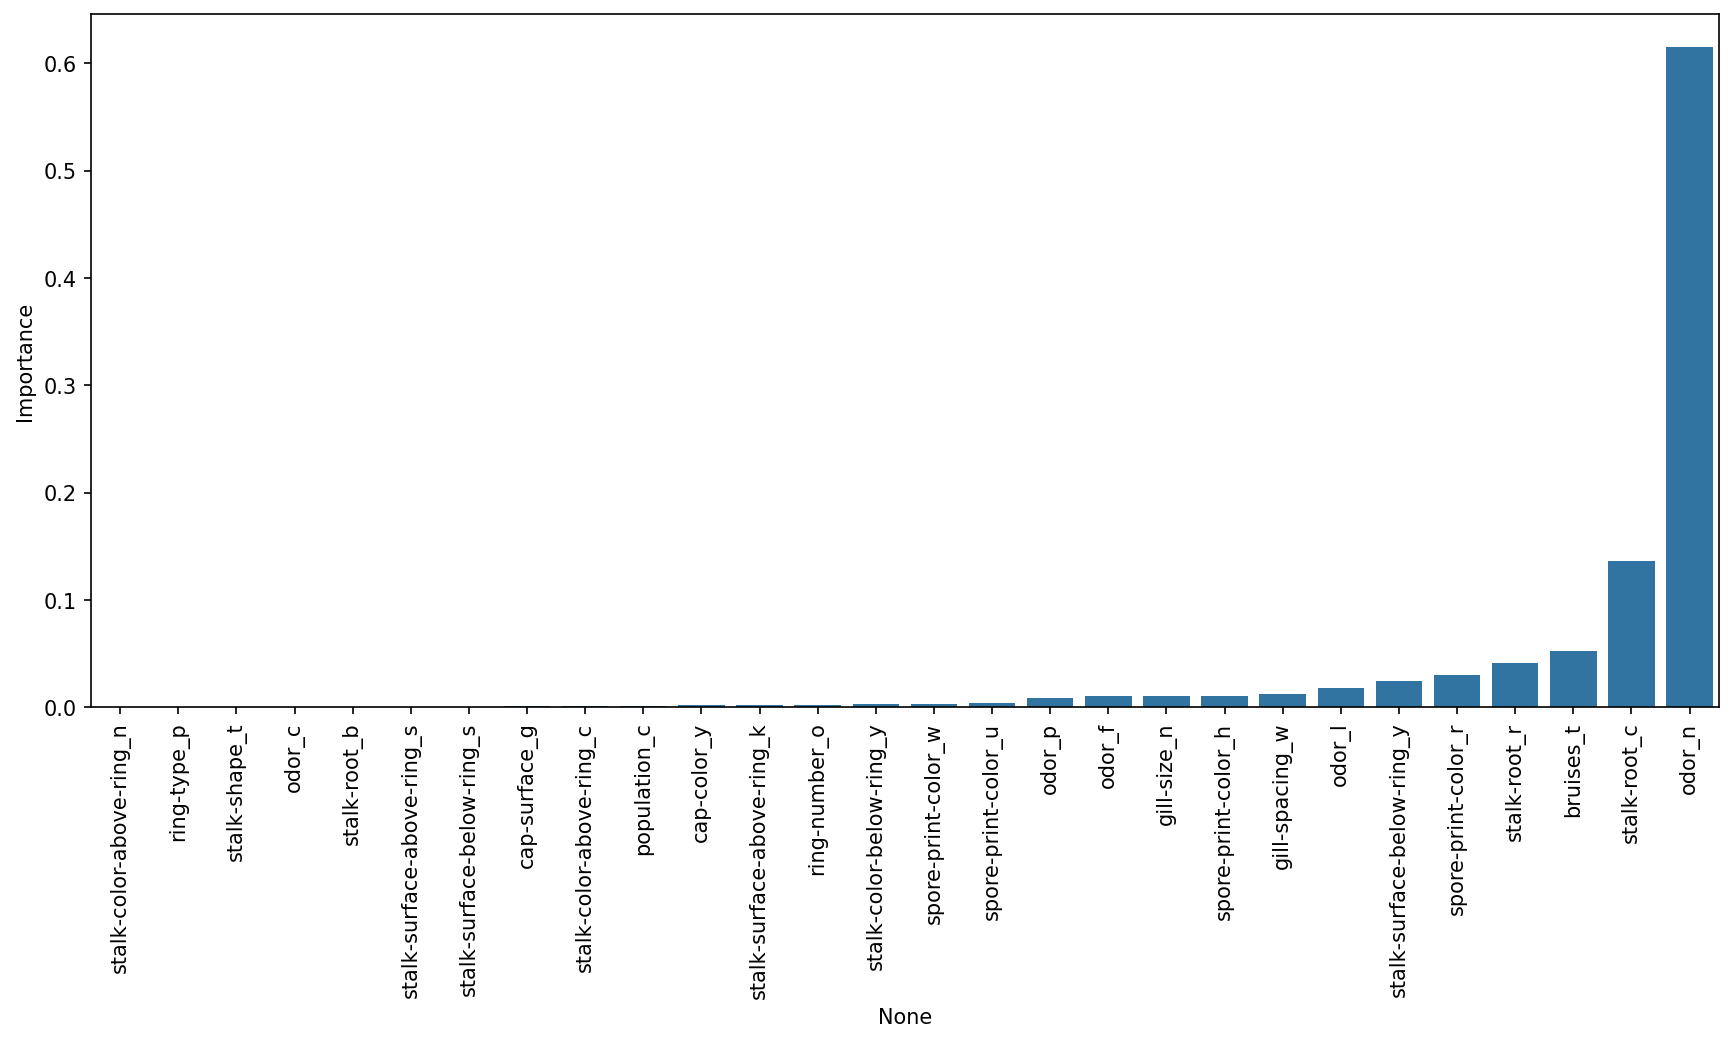

In [118]:
plt.figure(figsize=(14,6),dpi=150)
sns.barplot(data=imp_feat,x=imp_feat.index,y='Importance')
plt.xticks(rotation=90);

And once again the absence of odor becomes a defining feature for the mushroom to be edible.